# Chapter 5 — Causal AI for Robust, Explainable, and Adaptive Systems
## From Prediction Models to Decision Intelligence

**Course:** Causal Intelligence  
**Instructor:** Prof. Reza Arghandeh, Western Norway University of Applied Sciences, Norway  
**Year:** 2026

---

## Main purpose

This chapter explains why AI models need causal reasoning when they are used in the real world.

In earlier chapters, we learned how to move from prediction to causal questions, how to use causal graphs, how to estimate causal effects, and how to build a responsible causal analysis workflow. In this final chapter, we ask what happens after an AI model is trained and deployed.

The chapter focuses on three practical challenges:

1. **Robustness:** Will the model still work when the environment changes?
2. **Explainability:** Does the explanation show real causes and actionable mechanisms, or only predictive patterns?
3. **Adaptivity:** Can the system learn from new data, interventions, and policy changes over time?

We use a grid resilience example based on vegetation-related outage risk in overhead power-line corridors. A utility company wants to predict which line segments are at high risk of outage and decide where limited right-of-way maintenance should be prioritized before storm season.

The main lesson is that a model can perform well on historical data but fail after deployment if it learns unstable shortcuts, such as region or historical outage patterns. Causal intelligence helps us focus on more stable and actionable mechanisms, such as wind exposure, canopy encroachment, right-of-way clearance, infrastructure condition, and the effect of maintenance interventions.

The goal of the chapter is to show how causal reasoning can help transform AI from a static prediction model into a more reliable decision-support system.

## Chapter structure

1. From prediction models to deployed causal AI systems
2. Running example: grid resilience decision intelligence
3. Physics-inspired structural causal model for power outage risk
4. Generate historical and deployment environments
5. Visualizing distribution shift
6. Causal graph of the grid-resilience SCM
7. Robustness: random split vs. environment split
8. Spurious shortcuts and predictive explanations
9. Actionable causal explanations and heterogeneous intervention effects
10. Decision intelligence under a limited maintenance budget
11. Adaptivity: monitoring models, mechanisms, and interventions
12. Capstone checklist for causal AI deployment
13. Chapter summary
14. References and further reading


---
## 1. From prediction models to deployed causal AI systems

Most machine learning models are developed and evaluated under the assumption that the future will look similar to the past. If the training data, test data, and deployment data come from the same environment, a predictive model can be very useful.

However, real deployment is rarely so stable. After an AI model is deployed, the environment may change. Policies may change, users may adapt their behavior, weather conditions may become more extreme, sensors may be updated, and maintenance practices may improve. A model that performed well during development can therefore become unreliable in practice.

This is especially important in decision-support systems. A utility company, hospital, manufacturer, or public agency does not only want to know:

> *What is likely to happen?*

It also wants to know:

> *What can we change?*  
> *Will the model still work if the environment changes?*  
> *Which intervention is expected to help most?*

These are causal questions.

A prediction model estimates quantities such as:

$$E[Y \mid X=x]$$

This asks:

> *What outcome do we expect among units with observed features $X=x$?*

A causal model asks what would happen under an action or intervention:

$$E[Y \mid do(T=t)]$$

This asks:

> *What outcome would we expect if we actively set the treatment, policy, or action to $T=t$?*

This distinction becomes especially important after deployment. Future data may not follow the same distribution as the training data. A model that performs well under a random train-test split may fail when the deployment environment changes.

This is not only a technical problem. It is also a causal problem because the model may have learned unstable correlations rather than stable mechanisms.

In this chapter, we focus on three deployment questions:

| Pillar | Deployment question | Causal intelligence contribution |
|---|---|---|
| **Robustness** | Will the model still work when the environment changes? | Separate stable mechanisms from unstable shortcuts |
| **Explainability** | Does the explanation identify causes or only predictive signals? | Use causal graphs and interventions to distinguish actionable mechanisms |
| **Adaptivity** | Can the system learn from interventions over time? | Monitor causal mechanisms, treatment effects, and model drift |

The key message is:

> A deployed AI system should not only predict outcomes. It should support reliable decisions under changing conditions.

Relevant references: [Out-of-distribution generalization in time series: A survey (2025)](https://arxiv.org/abs/2503.13868), [A survey of out-of-distribution generalization for graph machine learning from a causal view (2024)](https://arxiv.org/html/2409.09858v1), and [The role of causality in explainable artificial intelligence (2025)](https://wires.onlinelibrary.wiley.com/doi/10.1002/widm.70015).


</br>

---
## Notebook setup: libraries and visual style

The notebook uses standard Python libraries so that it can run in a local Jupyter environment without heavy installation requirements.

We intentionally use `scikit-learn` rather than requiring specialized packages such as SHAP, XGBoost, or EconML. Optional extensions can be added later, but the core teaching notebook should remain easy to run.

In [1]:
# Basic imports used throughout the chapter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

# Harmonized visual style for the chapter
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "DejaVu Sans",
})

COLORS = {
    "navy": "#1f4e79",
    "orange": "#f28e2b",
    "green": "#59a14f",
    "red": "#e15759",
    "gray": "#7f7f7f",
    "light_blue": "#d8e8f5",
    "light_orange": "#fde6c8",
    "light_green": "#d9ead3",
    "light_red": "#f4cccc",
}

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def clean_axis(ax):
    """Apply a consistent, minimal style to matplotlib axes."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25)
    return ax

def display_df(df, decimals=3):
    """Display a rounded DataFrame."""
    display(df.round(decimals))

def rmse(y_true, y_pred):
    """Root mean squared error compatible across scikit-learn versions."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def draw_dag(edges, pos=None, title="Causal graph", node_colors=None, figsize=(12, 6), arrows=True):
    """Draw a directed graph with consistent style."""
    G = nx.DiGraph()
    G.add_edges_from(edges)
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
    node_colors = node_colors or {node: COLORS["light_blue"] for node in G.nodes()}
    colors = [node_colors.get(node, COLORS["light_blue"]) for node in G.nodes()]
    plt.figure(figsize=figsize)
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=3000,
        node_color=colors,
        edgecolors=COLORS["navy"],
        arrows=arrows,
        arrowsize=18,
        font_size=8.5,
        font_weight="bold",
        width=1.6,
    )
    plt.title(title)
    plt.axis("off")
    plt.show()
    return G

def make_preprocessor(df, features):
    """Create a preprocessing pipeline for numeric and categorical features."""
    categorical_features = [c for c in features if df[c].dtype == "object"]
    numeric_features = [c for c in features if c not in categorical_features]
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", "passthrough", numeric_features),
        ],
        remainder="drop"
    )
    return preprocessor, categorical_features, numeric_features

def fit_rf_model(train_df, features, target, seed=42, n_estimators=80, min_samples_leaf=8):
    """Fit a random forest regression model with one-hot encoding for categorical variables."""
    preprocessor, categorical_features, numeric_features = make_preprocessor(train_df, features)
    model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("rf", RandomForestRegressor(
            n_estimators=n_estimators,
            min_samples_leaf=8,
            random_state=seed,
            n_jobs=1
        ))
    ])
    model.fit(train_df[features], train_df[target])
    return model

def evaluate_model(model, df, features, target):
    """Evaluate model on a DataFrame."""
    pred = model.predict(df[features])
    return {
        "RMSE": rmse(df[target], pred),
        "R2": r2_score(df[target], pred)
    }

</br>

---
## 2. Running Example: Grid Resilience Decision Intelligence

We use one running example throughout this chapter: **vegetation-related outage risk in overhead power-line corridors**.

### Scenario

A utility company wants to predict and reduce outage risk along overhead power-line corridors. The company has historical data about weather, vegetation, land cover, power-line characteristics, maintenance, inspection, and outage events.

The company has a limited maintenance budget and can perform enhanced right-of-way maintenance on only **20%** of line segments before storm season.

The ordinary prediction question is:

> *Which line segments are most likely to experience an outage?*

The causal decision question is:

> *Which line segments would benefit most if we performed enhanced right-of-way maintenance?*

These questions are different. A high-risk segment is not always the segment where maintenance produces the largest risk reduction. A causal AI system should estimate not only risk, but also **intervention benefit**.

<div style="text-align: center;">
  <img src="img/CH05/Tree_Fall_Power_Line.png" alt="Tree Fall on a Power Line" width="700"/>
</div>

### Unit, treatment, outcome, and estimand

| Component | Definition in this chapter |
|---|---|
| Unit | One overhead power-line corridor segment |
| Treatment | Enhanced right-of-way maintenance before storm season |
| Treatment notation | $T=1$ means enhanced maintenance; $T=0$ means normal maintenance |
| Outcome | Vegetation-related outage risk score |
| Binary event | Vegetation-related outage occurrence |
| Main estimands | $E[Y(1)-Y(0)]$ and $E[Y(1)-Y(0) \mid X=x]$ |
| Decision objective | Allocate a limited maintenance budget to maximize avoided outage risk |

Because lower outage risk is better, a negative treatment effect means that enhanced maintenance reduces outage risk.

Relevant recent references for the domain motivation: [Non-parametric machine learning modeling of tree-related outage risks (2024)](https://www.sciencedirect.com/science/article/pii/S0378779623011016), [Advancing outage prediction modeling: Incorporating circuit spatial relationships with graph neural networks and lidar-derived tree risk (2025)](https://www.sciencedirect.com/science/article/pii/S0378779625004962), [Detection of vegetation proximity to power lines: A review (2025)](https://www.sciencedirect.com/science/article/pii/S0924271625000476), and [Predicting the risk of individual tree fall along powerlines (2026)](https://www.sciencedirect.com/science/article/pii/S0378112725006574).


### Observed Variable Groups

We use domain-specific variables so that the example sounds like a real operational problem rather than a toy dataset.

| Group | Variables | Interpretation |
|---|---|---|
| Weather and hazard | `StormSeverity`, `WindGustSpeed`, `SnowLoad`, `SoilMoisture` | External hazard exposure |
| Vegetation and land cover | `VegetationType`, `LandCoverType`, `VegetationDensity`, `CanopyHeight`, `CanopyEncroachment`, `EdgeExposure` | Vegetation exposure and contact risk |
| Infrastructure | `VoltageLevel`, `LineType`, `PoleHeight`, `ConductorHeight`, `LineAgeYears`, `AssetHealthIndex`, `ProtectionAutomation` | Asset vulnerability and clearance geometry |
| Maintenance | `RoWClearanceMeters`, `TimeSinceRoWMaintenance`, `InspectionFrequency`, `EnhancedRoWMaintenance` | Intervention and operational context |
| Proxy variables | `Region`, `HistoricalOutageRate` | Predictive shortcuts that may fail under shift |
| Outcome | `OutageRiskScore`, `VegetationRelatedOutage` | Risk score and observed event |
| Hidden variable | `UtilityBudget` | Unobserved confounder affecting inspection, maintenance, and asset quality |

The hidden variable `UtilityBudget` is not included in the observed feature set. It is used in the simulation to create realistic confounding.

In [2]:
variable_table = pd.DataFrame({
    "Variable": [
        "Region", "StormSeverity", "WindGustSpeed", "SnowLoad", "SoilMoisture",
        "VegetationType", "LandCoverType", "VegetationDensity", "CanopyHeight",
        "CanopyEncroachment", "EdgeExposure", "VoltageLevel", "LineType",
        "PoleHeight", "ConductorHeight", "LineAgeYears", "AssetHealthIndex",
        "ProtectionAutomation", "RoWClearanceMeters", "TimeSinceRoWMaintenance",
        "InspectionFrequency", "EnhancedRoWMaintenance", "HistoricalOutageRate",
        "OutageRiskScore", "VegetationRelatedOutage"
    ],
    "Role": [
        "Proxy for geography, climate, land cover, maintenance history",
        "Latent storm intensity observed through weather variables",
        "Nonlinear hazard driver; wind load grows approximately with wind speed squared",
        "Snow/ice loading and storm stress",
        "Amplifies uprooting and windthrow risk",
        "Species/vegetation class; affects fragility",
        "Context for forest, wetland, agricultural, or urban corridor",
        "Amount of vegetation near corridor",
        "Height of vegetation near line",
        "Vegetation proximity/contact indicator",
        "Exposed forest edge near corridor",
        "Infrastructure class",
        "Overhead line type",
        "Pole/tower height",
        "Conductor height above ground",
        "Asset age",
        "Overall infrastructure condition index",
        "Protection and automation capability",
        "Right-of-way clearance width",
        "Time since maintenance intervention",
        "Inspection and monitoring frequency",
        "Treatment/intervention",
        "Historical region-level risk proxy",
        "Continuous outcome: predicted/true outage risk probability",
        "Binary observed event"
    ],
    "Use in causal interpretation?": [
        "Treat carefully; proxy rather than intervention target",
        "Hazard context", "Hazard mechanism", "Hazard mechanism", "Hazard amplifier",
        "Mechanism", "Context", "Mechanism", "Mechanism", "Mechanism",
        "Mechanism", "Infrastructure context", "Infrastructure context",
        "Infrastructure mechanism", "Infrastructure mechanism", "Infrastructure vulnerability",
        "Infrastructure vulnerability", "Protection mechanism",
        "Intervention mechanism", "Intervention history", "Potential proxy/confounded variable",
        "Treatment", "Shortcut/proxy", "Outcome", "Observed outcome"
    ]
})
display_df(variable_table, decimals=3)

,Variable,Role,Use in causal interpretation?
0,Region,"Proxy for geography, climate, land cover, main...",Treat carefully; proxy rather than interventio...
1,StormSeverity,Latent storm intensity observed through weathe...,Hazard context
2,WindGustSpeed,Nonlinear hazard driver; wind load grows appro...,Hazard mechanism
3,SnowLoad,Snow/ice loading and storm stress,Hazard mechanism
4,SoilMoisture,Amplifies uprooting and windthrow risk,Hazard amplifier
5,VegetationType,Species/vegetation class; affects fragility,Mechanism
6,LandCoverType,"Context for forest, wetland, agricultural, or ...",Context
7,VegetationDensity,Amount of vegetation near corridor,Mechanism
8,CanopyHeight,Height of vegetation near line,Mechanism
9,CanopyEncroachment,Vegetation proximity/contact indicator,Mechanism


</br>

---
## 3. Physics-inspired Structural Causal Model for Power Outage Risk

The synthetic data in this chapter are generated from a simplified [Structural Causal Model (SCM)](https://github.com/Ci2Lab/Applied_Causal_Inference_Course/blob/main/lectures/CH-4-Structural-Causal-Models.ipynb). The goal is not to reproduce one specific utility dataset. Instead, the goal is to create a realistic teaching example where the main relationships reflect plausible mechanisms behind vegetation-related power outages.

The model is called **physics-inspired** because it includes simple versions of mechanisms that are meaningful in power-line corridor risk:

- wind creates mechanical stress on trees and power lines;
- vegetation becomes risky when it is too close to conductors;
- wet soil and exposed forest edges increase windthrow risk;
- older or lower-health assets are more vulnerable;
- protection and automation can reduce the probability or impact of outages.

The outcome is a binary outage event:

$$Y = 1$$

means that a vegetation-related outage occurs, while:

$$Y = 0$$

means that no outage occurs.

The SCM is simplified, but it helps us teach an important idea:

> Outage risk is not caused by one variable alone. It emerges from interactions between weather, vegetation, land cover, infrastructure, and maintenance.

### Wind load

Wind impact is nonlinear. A small increase in wind speed can create a much larger increase in mechanical stress. A simple teaching approximation is:

$$WindLoad = \left(\frac{WindGustSpeed}{30}\right)^2$$

Here, `WindGustSpeed` is scaled by 30 to keep the values in a reasonable range for the simulation.

### Contact risk

Vegetation becomes risky when canopy height and canopy encroachment are large relative to the available clearance between vegetation and conductors.

We approximate this using:

$$ContactRisk = \sigma(CanopyHeight + CanopyEncroachment - ConductorHeight - RoWClearanceMeters)$$

where $\sigma(\cdot)$ is the sigmoid function.

The intuition is simple:

- higher canopy height increases contact risk;
- higher canopy encroachment increases contact risk;
- higher conductor height reduces contact risk;
- wider right-of-way clearance reduces contact risk.

The sigmoid function transforms this mechanism into a value between 0 and 1. Values close to 0 indicate low contact risk, while values close to 1 indicate high contact risk.

### Windthrow risk

A tree does not need to touch a conductor under normal conditions to become dangerous. During storms, trees can break, bend, or fall into the corridor. This is called windthrow risk.

We approximate windthrow risk as:

$$WindthrowRisk = \sigma(WindLoad + SoilMoisture + EdgeExposure + VegetationFragility)$$

The intuition is:

- stronger wind increases windthrow risk;
- wetter soil can make trees easier to uproot;
- exposed forest edges are more vulnerable to wind;
- fragile vegetation types are more likely to break or fall.

Again, the sigmoid function keeps the risk value between 0 and 1.

### Infrastructure vulnerability

The same vegetation and weather conditions may have different consequences depending on the condition of the grid asset. Older or lower-health assets are usually more vulnerable.

We define:

$$InfrastructureVulnerability = 1 - \frac{AssetHealthIndex}{100}$$

Here, `AssetHealthIndex` ranges from 0 to 100. A high asset health index means low vulnerability, while a low asset health index means high vulnerability.

### Outage risk

The probability of a vegetation-related outage combines several mechanisms: weather hazard, vegetation contact, windthrow, infrastructure vulnerability, and protection or automation.

We write the outage probability as:

$$P(Y=1) = \sigma(\alpha + \beta_1 WindLoad + \beta_2 ContactRisk + \beta_3 WindthrowRisk + \beta_4 InfrastructureVulnerability - \beta_5 ProtectionAutomation)$$

where $\sigma(\cdot)$ is the sigmoid function. The sigmoid function transforms the score inside the parentheses into a probability between 0 and 1.

The terms inside the parentheses form a **risk score**:

$$RiskScore = \alpha + \beta_1 WindLoad + \beta_2 ContactRisk + \beta_3 WindthrowRisk + \beta_4 InfrastructureVulnerability - \beta_5 ProtectionAutomation$$

The coefficients $\beta_1, \beta_2, \beta_3, \beta_4,$ and $\beta_5$ are simulation parameters. They determine how strongly each mechanism contributes to outage risk.

For example:

- $\beta_1$ controls how strongly wind load increases outage risk.
- $\beta_2$ controls how strongly vegetation contact risk increases outage risk.
- $\beta_3$ controls how strongly windthrow risk increases outage risk.
- $\beta_4$ controls how strongly infrastructure vulnerability increases outage risk.
- $\beta_5$ controls how strongly protection and automation reduce outage risk.

The negative sign before $\beta_5 ProtectionAutomation$ means that better protection and automation reduce outage probability, assuming $\beta_5 > 0$.

For this teaching simulation, these coefficients are chosen by the instructor to create plausible synthetic data. They are not estimated from a real utility dataset. In a real utility study, these parameters would need to be estimated, calibrated, and validated using operational outage records, weather data, vegetation information, asset data, and maintenance history.

The equation says that outage risk increases when wind load, contact risk, windthrow risk, or infrastructure vulnerability increases. It decreases when protection and automation are stronger.

This creates a nonlinear and mechanism-informed data-generating process. The purpose is to make the synthetic data realistic enough to teach robustness, explainability, and adaptivity, while still keeping the model simple enough to understand in one lecture.

### Treatment effect

The treatment in this chapter is **enhanced right-of-way maintenance**. In practice, this may mean more frequent vegetation management, wider clearance, or targeted trimming before storm season.

In the simulation, enhanced maintenance increases right-of-way clearance and reduces the time since the last maintenance action.

Using potential-outcome notation:

$Y_i(0)$ is the outage risk for line segment $i$ under normal maintenance.

$Y_i(1)$ is the outage risk for line segment $i$ under enhanced maintenance.

The individual treatment effect is:

$$\tau_i = Y_i(1) - Y_i(0)$$

Because lower outage risk is better, a negative treatment effect means that maintenance is beneficial:

$$\tau_i < 0$$

This means that enhanced maintenance reduces the outage risk for line segment $i$.

The treatment effect is not expected to be the same for all line segments. Enhanced maintenance may be most beneficial for segments with high wind exposure, high canopy encroachment, fragile vegetation, or low infrastructure health. This is why the chapter later studies heterogeneous treatment effects and maintenance prioritization.

<div style="text-align: center;">
  <img 
    src="img/CH05/Physics_Causal_Model.png" 
    alt="Physics-inspired Structural Causal Model" 
    style="max-width: 100%; height: auto;"
  />
</div>

</br>

Relevant recent references: [Risk assessment of distribution networks considering vegetation attributes (2025)](https://arxiv.org/pdf/2503.09239), [Dynamic modeling of the effects of vegetation management on weather-related power outages (2022)](https://doi.org/10.1016/j.epsr.2022.107840), and [DOE Vegetation Management Resilience Investment Guide (2024)](https://www.energy.gov/sites/default/files/2024-11/111524_Vegetation_Management.pdf).

The next code cell defines the data-generating process for the Grid Resilience example.

The simulation creates synthetic power-line corridor data using the simplified physics-inspired SCM introduced above. Because the data are synthetic, we also know the potential outage risks under normal and enhanced right-of-way maintenance. This allows us to study prediction, distribution shift, causal effects, and maintenance prioritization in one example.


In [3]:
def compute_risk_components(df, clearance_col, time_col):
    """Compute physics-inspired risk components for a given clearance and maintenance-time scenario."""
    wind_load = (df["WindGustSpeed"] / 30.0) ** 2
    infrastructure_vulnerability = 1 - (df["AssetHealthIndex"] / 100.0)

    effective_encroachment = (
        df["CanopyEncroachment"]
        + 0.04 * df[time_col]
        + 0.02 * df["VegetationDensity"]
        - 0.03 * df[clearance_col]
    )

    contact_risk = sigmoid(
        0.75 * (df["CanopyHeight"] + 2.5 * effective_encroachment
                - df["ConductorHeight"] - 0.6 * df[clearance_col])
    )

    canopy_support = np.where(df["VegetationDensity"] > 0.70, -0.25, 0.0)
    windthrow_risk = sigmoid(
        -2.0
        + 0.95 * wind_load
        + 1.05 * df["SoilMoisture"]
        + 0.85 * df["EdgeExposure"]
        + 0.75 * df["VegetationFragility"]
        + canopy_support
    )

    linear_risk = (
        -3.1
        + 0.85 * wind_load
        + 1.35 * contact_risk
        + 1.10 * windthrow_risk
        + 0.95 * infrastructure_vulnerability
        + 0.25 * df["SnowLoad"]
        - 0.80 * df["ProtectionAutomation"]
    )

    outage_risk = sigmoid(linear_risk)

    return pd.DataFrame({
        "WindLoad": wind_load,
        "ContactRisk": contact_risk,
        "WindthrowRisk": windthrow_risk,
        "InfrastructureVulnerability": infrastructure_vulnerability,
        "OutageRisk": outage_risk
    })


def simulate_grid_environment(n=2500, environment="Historical", seed=42):
    """Simulate a grid-resilience dataset with three deployment environments."""
    rng = np.random.default_rng(seed)

    if environment == "Historical":
        regions = rng.choice(["Region_A", "Region_B", "Region_C"], size=n, p=[0.40, 0.35, 0.25])
        policy_shift = 0.0
        new_region_shift = 0.0
    elif environment == "NewPolicy":
        regions = rng.choice(["Region_A", "Region_B", "Region_C"], size=n, p=[0.40, 0.35, 0.25])
        policy_shift = 1.0
        new_region_shift = 0.0
    elif environment == "NewRegion":
        regions = rng.choice(["Region_D", "Region_E"], size=n, p=[0.55, 0.45])
        policy_shift = 0.35
        new_region_shift = 1.0
    else:
        raise ValueError("environment must be Historical, NewPolicy, or NewRegion")

    region_params = {
        "Region_A": {"budget": -0.7, "weather": 0.2, "old_assets": 0.8, "hist_rate": 0.22},
        "Region_B": {"budget": 0.6, "weather": -0.2, "old_assets": -0.3, "hist_rate": 0.10},
        "Region_C": {"budget": 0.0, "weather": 0.7, "old_assets": 0.2, "hist_rate": 0.17},
        "Region_D": {"budget": 0.1, "weather": 0.6, "old_assets": -0.1, "hist_rate": 0.16},
        "Region_E": {"budget": -0.2, "weather": -0.1, "old_assets": 0.5, "hist_rate": 0.14},
    }

    budget_mean = np.array([region_params[r]["budget"] for r in regions])
    weather_region = np.array([region_params[r]["weather"] for r in regions])
    asset_region = np.array([region_params[r]["old_assets"] for r in regions])
    historical_outage_rate = np.array([region_params[r]["hist_rate"] for r in regions])

    utility_budget = rng.normal(budget_mean + 0.35 * policy_shift, 0.6, n)

    storm_severity = rng.normal(weather_region + 0.15 * new_region_shift, 0.8, n)
    wind_gust_speed = np.clip(22 + 7.5 * storm_severity + rng.normal(0, 4.5, n), 5, 55)
    precipitation = np.clip(10 + 8.0 * storm_severity + rng.normal(0, 5.0, n), 0, 60)
    snow_load = np.clip(0.15 + 0.08 * storm_severity + rng.normal(0, 0.10, n), 0, 0.8)
    soil_moisture = np.clip(sigmoid(-0.6 + 0.05 * precipitation + 0.5 * storm_severity + rng.normal(0, 0.6, n)), 0, 1)
    terrain_exposure = np.clip(sigmoid(0.2 + 0.5 * weather_region + rng.normal(0, 0.8, n)), 0, 1)

    land_cover_options = ["ConiferForest", "MixedForest", "Agricultural", "Wetland", "UrbanEdge"]
    vegetation_options = ["Spruce", "Pine", "Deciduous", "Mixed", "Shrub"]

    land_cover = []
    vegetation_type = []
    for r in regions:
        if r in ["Region_A"]:
            land_cover.append(rng.choice(land_cover_options, p=[0.55, 0.20, 0.05, 0.15, 0.05]))
            vegetation_type.append(rng.choice(vegetation_options, p=[0.50, 0.20, 0.10, 0.15, 0.05]))
        elif r in ["Region_C", "Region_D"]:
            land_cover.append(rng.choice(land_cover_options, p=[0.25, 0.30, 0.05, 0.25, 0.15]))
            vegetation_type.append(rng.choice(vegetation_options, p=[0.25, 0.20, 0.20, 0.30, 0.05]))
        else:
            land_cover.append(rng.choice(land_cover_options, p=[0.15, 0.25, 0.25, 0.10, 0.25]))
            vegetation_type.append(rng.choice(vegetation_options, p=[0.15, 0.20, 0.35, 0.20, 0.10]))

    land_cover = np.array(land_cover)
    vegetation_type = np.array(vegetation_type)

    fragility_map = {"Spruce": 0.85, "Pine": 0.55, "Deciduous": 0.45, "Mixed": 0.60, "Shrub": 0.20}
    vegetation_fragility = np.array([fragility_map[v] for v in vegetation_type])

    forest_indicator = np.isin(land_cover, ["ConiferForest", "MixedForest", "Wetland"]).astype(float)
    vegetation_density = np.clip(
        0.35 + 0.25 * forest_indicator + 0.12 * (vegetation_type == "Spruce").astype(float)
        - 0.10 * utility_budget + rng.normal(0, 0.15, n),
        0.05, 0.98
    )
    canopy_height = np.clip(
        7 + 8 * forest_indicator + 6 * vegetation_density + 3 * (vegetation_type == "Spruce").astype(float)
        + rng.normal(0, 2.5, n),
        1, 32
    )
    edge_exposure = np.clip(
        sigmoid(-0.4 + 1.2 * forest_indicator + 0.7 * terrain_exposure + 0.4 * new_region_shift + rng.normal(0, 0.7, n)),
        0, 1
    )

    voltage_level = rng.choice(["LowVoltage", "MediumVoltage", "HighVoltage"], size=n, p=[0.45, 0.40, 0.15])
    line_type = np.where(voltage_level == "LowVoltage", "Distribution",
                         np.where(voltage_level == "MediumVoltage", "SubTransmission", "Transmission"))

    voltage_pole_base = np.select(
        [voltage_level == "LowVoltage", voltage_level == "MediumVoltage", voltage_level == "HighVoltage"],
        [9.0, 14.0, 24.0]
    )
    pole_height = np.clip(voltage_pole_base + rng.normal(0, 1.5, n), 6, 30)
    conductor_height = np.clip(pole_height - rng.normal(1.5, 0.7, n), 5, 29)

    line_age_years = np.clip(22 + 8 * asset_region - 4.0 * utility_budget + rng.normal(0, 7, n), 1, 60)
    asset_health_index = np.clip(92 - 1.1 * line_age_years + 5.0 * utility_budget + rng.normal(0, 6, n), 10, 100)
    protection_automation = np.clip(sigmoid(-0.3 + 0.7 * utility_budget + 0.4 * (voltage_level == "HighVoltage").astype(float)), 0, 1)

    maintenance_policy = sigmoid(-0.2 + 0.8 * utility_budget + 1.4 * policy_shift)
    time_since_row_maintenance = np.clip(4.5 - 2.6 * maintenance_policy + rng.normal(0, 1.2, n), 0.1, 8.0)
    row_clearance_meters = np.clip(3.5 + 2.4 * maintenance_policy + 1.2 * policy_shift - 0.35 * vegetation_density + rng.normal(0, 0.8, n), 0.5, 10.0)
    inspection_frequency = np.clip(1.0 + 2.3 * sigmoid(utility_budget) + 0.5 * policy_shift + rng.normal(0, 0.5, n), 0.2, 6.0)

    canopy_encroachment = np.clip(
        sigmoid(-1.2 + 0.20 * canopy_height - 0.45 * row_clearance_meters + 0.38 * time_since_row_maintenance
                + 0.65 * vegetation_density + rng.normal(0, 0.5, n)),
        0, 1
    )

    risk_proxy = (
        0.55 * canopy_encroachment
        + 0.25 * vegetation_density
        + 0.20 * (wind_gust_speed / 40.0)
        + 0.15 * (1 - asset_health_index / 100.0)
    )
    p_treat = sigmoid(-1.3 + 2.0 * risk_proxy + 0.7 * utility_budget + 0.8 * policy_shift)
    enhanced_row_maintenance = rng.binomial(1, p_treat, n)

    observed = pd.DataFrame({
        "Environment": environment,
        "Region": regions,
        "StormSeverity": storm_severity,
        "WindGustSpeed": wind_gust_speed,
        "Precipitation": precipitation,
        "SnowLoad": snow_load,
        "SoilMoisture": soil_moisture,
        "TerrainExposure": terrain_exposure,
        "LandCoverType": land_cover,
        "VegetationType": vegetation_type,
        "VegetationFragility": vegetation_fragility,
        "VegetationDensity": vegetation_density,
        "CanopyHeight": canopy_height,
        "EdgeExposure": edge_exposure,
        "VoltageLevel": voltage_level,
        "LineType": line_type,
        "PoleHeight": pole_height,
        "ConductorHeight": conductor_height,
        "LineAgeYears": line_age_years,
        "AssetHealthIndex": asset_health_index,
        "ProtectionAutomation": protection_automation,
        "RoWClearanceMeters": row_clearance_meters,
        "TimeSinceRoWMaintenance": time_since_row_maintenance,
        "InspectionFrequency": inspection_frequency,
        "CanopyEncroachment": canopy_encroachment,
        "EnhancedRoWMaintenance": enhanced_row_maintenance,
        "HistoricalOutageRate": historical_outage_rate,
    })

    df0 = observed.copy()
    df0["RoWClearance_0"] = observed["RoWClearanceMeters"]
    df0["TimeSinceMaintenance_0"] = observed["TimeSinceRoWMaintenance"]

    df1 = observed.copy()
    df1["RoWClearance_1"] = np.clip(observed["RoWClearanceMeters"] + 2.4 + 0.6 * policy_shift, 0.5, 12.0)
    df1["TimeSinceMaintenance_1"] = np.clip(observed["TimeSinceRoWMaintenance"] - 2.0, 0.1, 8.0)

    risk0 = compute_risk_components(df0.assign(
        RoWClearanceScenario=df0["RoWClearance_0"],
        TimeSinceMaintenanceScenario=df0["TimeSinceMaintenance_0"]
    ), "RoWClearanceScenario", "TimeSinceMaintenanceScenario")

    risk1 = compute_risk_components(df1.assign(
        RoWClearanceScenario=df1["RoWClearance_1"],
        TimeSinceMaintenanceScenario=df1["TimeSinceMaintenance_1"]
    ), "RoWClearanceScenario", "TimeSinceMaintenanceScenario")

    observed["RiskNoEnhancedMaintenance"] = risk0["OutageRisk"].values
    observed["RiskEnhancedMaintenance"] = risk1["OutageRisk"].values
    observed["TrueTreatmentEffect"] = observed["RiskEnhancedMaintenance"] - observed["RiskNoEnhancedMaintenance"]

    observed["OutageRiskScore"] = np.where(
        observed["EnhancedRoWMaintenance"] == 1,
        observed["RiskEnhancedMaintenance"],
        observed["RiskNoEnhancedMaintenance"]
    )

    observed["VegetationRelatedOutage"] = rng.binomial(1, observed["OutageRiskScore"].clip(0, 1), n)

    coord_center = {
        "Region_A": (0, 0), "Region_B": (4, 0), "Region_C": (2, 3),
        "Region_D": (7, 2), "Region_E": (9, -1)
    }
    observed["x_coord"] = np.array([coord_center[r][0] for r in regions]) + rng.normal(0, 0.7, n)
    observed["y_coord"] = np.array([coord_center[r][1] for r in regions]) + rng.normal(0, 0.7, n)

    hidden = pd.DataFrame({
        "UtilityBudget": utility_budget,
        "p_EnhancedRoWMaintenance": p_treat,
        "WindLoad": risk0["WindLoad"].values,
        "ContactRisk_NoMaintenance": risk0["ContactRisk"].values,
        "ContactRisk_EnhancedMaintenance": risk1["ContactRisk"].values,
        "WindthrowRisk": risk0["WindthrowRisk"].values,
        "InfrastructureVulnerability": risk0["InfrastructureVulnerability"].values,
    })

    return observed, hidden

</br>

---
## 4. Generate Historical and Deployment Environments

We now generate three environments to represent different stages of model development and deployment.

1. **Historical**: the original training environment. In this setting, regional patterns are stable, so variables such as `Region` and `HistoricalOutageRate` may look highly predictive.

2. **NewPolicy**: the same broad regions, but with a new vegetation-management policy. Right-of-way clearance improves, and the time since last maintenance decreases. This changes the relationship between region, maintenance, and outage risk.

3. **NewRegion**: a new deployment geography with a different mix of vegetation types, land-cover conditions, weather exposure, and infrastructure characteristics. This tests whether the model has learned general mechanisms or only historical regional shortcuts.

The purpose is to compare two types of evaluation:

- **Random train-test evaluation**, where training and test data come from the same mixed historical environment.
- **Environment-based deployment evaluation**, where the model is tested under policy or geographic changes.

This distinction is central to the chapter: a model can perform well under a random split but fail when the deployment environment changes.

In [4]:
historical, hidden_historical = simulate_grid_environment(n=2200, environment="Historical", seed=42)
new_policy, hidden_new_policy = simulate_grid_environment(n=1600, environment="NewPolicy", seed=43)
new_region, hidden_new_region = simulate_grid_environment(n=1600, environment="NewRegion", seed=44)

grid = pd.concat([historical, new_policy, new_region], ignore_index=True)
grid.head()

,Environment,Region,StormSeverity,WindGustSpeed,Precipitation,SnowLoad,SoilMoisture,TerrainExposure,LandCoverType,VegetationType,...,CanopyEncroachment,EnhancedRoWMaintenance,HistoricalOutageRate,RiskNoEnhancedMaintenance,RiskEnhancedMaintenance,TrueTreatmentEffect,OutageRiskScore,VegetationRelatedOutage,x_coord,y_coord
0,Historical,Region_C,0.771148,26.621172,26.021637,0.329112,0.656049,0.578260,Agricultural,Mixed,...,0.321218,0,0.17,0.163993,0.158344,-0.005649,0.163993,0,2.980148,3.183627
1,Historical,Region_B,-1.371626,11.145466,0.000000,0.153559,0.218486,0.415110,MixedForest,Spruce,...,0.973010,0,0.10,0.283705,0.283672,-0.000033,0.283705,0,4.037333,1.166366
2,Historical,Region_C,-0.121784,18.127029,13.344714,0.076148,0.619916,0.485322,Wetland,Shrub,...,0.586131,1,0.17,0.265836,0.265004,-0.000833,0.265004,1,1.985874,3.085651
3,Historical,Region_B,-0.800558,16.285923,1.196021,0.245467,0.367436,0.370350,MixedForest,Mixed,...,0.914558,1,0.10,0.226399,0.225937,-0.000462,0.225937,1,3.519354,-0.646389
4,Historical,Region_A,0.875151,31.390306,17.277406,0.224542,0.796069,0.837897,Agricultural,Mixed,...,0.350425,0,0.22,0.269059,0.238667,-0.030392,0.269059,0,-1.959381,0.091213


In [5]:
summary_env = grid.groupby("Environment").agg(
    segments=("OutageRiskScore", "size"),
    mean_wind_gust=("WindGustSpeed", "mean"),
    mean_clearance=("RoWClearanceMeters", "mean"),
    mean_time_since_maintenance=("TimeSinceRoWMaintenance", "mean"),
    mean_encroachment=("CanopyEncroachment", "mean"),
    mean_asset_health=("AssetHealthIndex", "mean"),
    mean_outage_risk=("OutageRiskScore", "mean"),
    observed_outage_rate=("VegetationRelatedOutage", "mean"),
    mean_true_treatment_effect=("TrueTreatmentEffect", "mean")
)
display_df(summary_env)

,segments,mean_wind_gust,mean_clearance,mean_time_since_maintenance,mean_encroachment,mean_asset_health,mean_outage_risk,observed_outage_rate,mean_true_treatment_effect
Environment,,,,,,,,,
Historical,2200,23.524,4.345,3.315,0.794,64.580,0.305,0.297,-0.013
NewPolicy,1600,23.189,6.383,2.509,0.621,68.206,0.269,0.271,-0.018
NewRegion,1600,25.418,5.144,2.984,0.714,67.395,0.302,0.309,-0.018


### Interpretation

The environment summary is a descriptive diagnostic. It helps us check whether the deployment environments differ from the historical training environment. It should not be interpreted as a causal estimate.

The table shows that the three environments are not identical. For example, the `NewPolicy` environment has higher average clearance and lower time since maintenance than the `Historical` environment. This reflects the intended policy change: vegetation management has improved before deployment.

The `NewRegion` environment has a different weather and infrastructure profile. It has higher average wind gust speed and a different level of canopy encroachment and asset health compared with the historical data. This means the model is being tested in a setting that is not simply another random sample from the training environment.

The most important variables for this chapter are `mean_clearance`, `mean_time_since_maintenance`, and `mean_encroachment`. These variables can change after maintenance policies are updated, and they directly affect the relationship between region and outage risk.

The key lesson is:

> Deployment data may look similar to training data in some ways, but important mechanisms can still change. This is why random train-test evaluation is not enough for robust AI.

</br>

---
## 5. Visualizing Distribution Shift

A standard machine learning workflow often assumes that training and test data are independent and identically distributed. In deployment, this assumption is often violated.

We compare the distributions of several key variables across environments:

- `TimeSinceRoWMaintenance`
- `RoWClearanceMeters`
- `CanopyEncroachment`
- `WindGustSpeed`

The goal is to make distribution shift visible before evaluating model robustness.


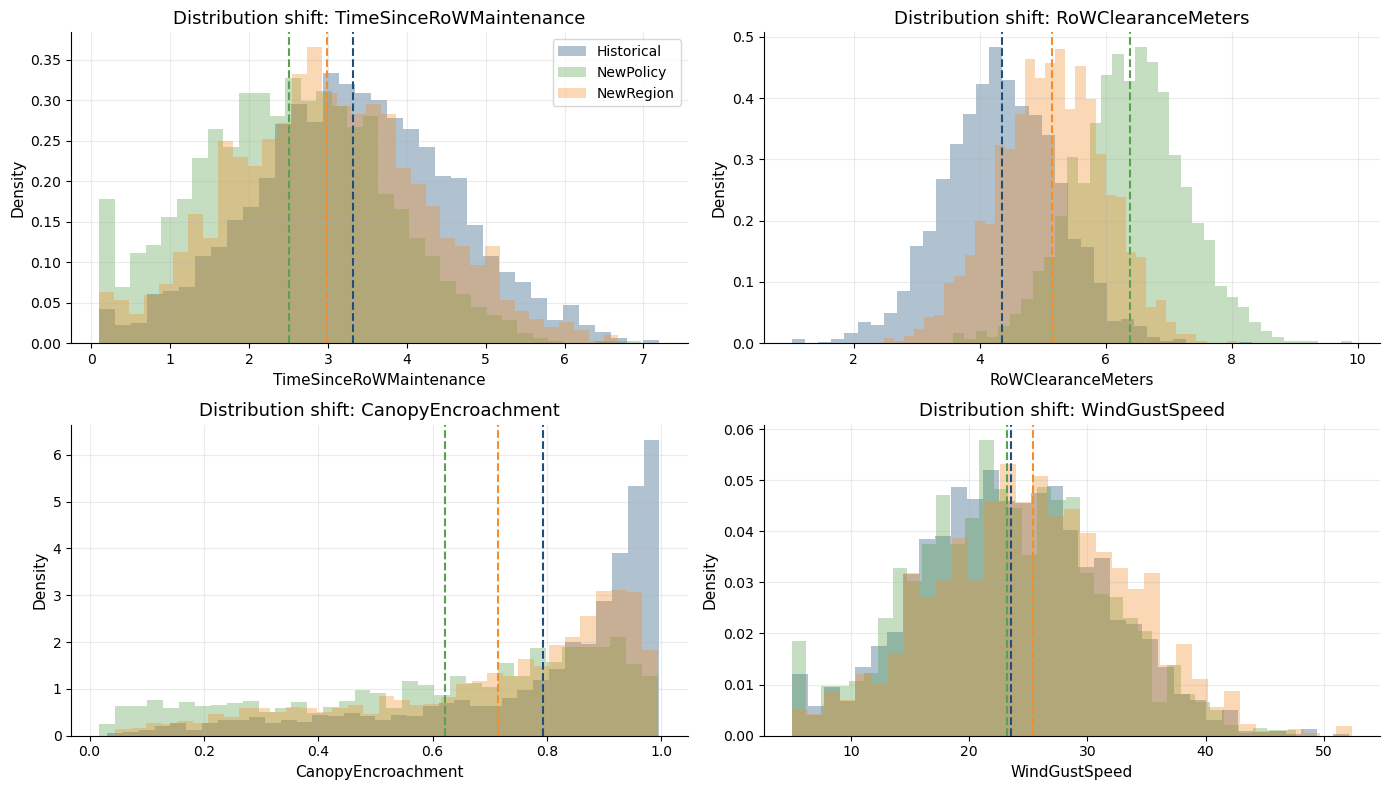

In [6]:
shift_vars = [
    "TimeSinceRoWMaintenance",
    "RoWClearanceMeters",
    "CanopyEncroachment",
    "WindGustSpeed"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

env_colors = {
    "Historical": COLORS["navy"],
    "NewPolicy": COLORS["green"],
    "NewRegion": COLORS["orange"]
}

for ax, var in zip(axes, shift_vars):
    for env, color in env_colors.items():
        values = grid.loc[grid["Environment"] == env, var]
        ax.hist(values, bins=35, alpha=0.35, density=True, label=env, color=color)
        ax.axvline(values.mean(), color=color, linestyle="--", linewidth=1.5)
    ax.set_title(f"Distribution shift: {var}")
    ax.set_xlabel(var)
    ax.set_ylabel("Density")
    clean_axis(ax)

axes[0].legend()
plt.tight_layout()
plt.show()

### Interpretation

The dashed vertical lines show the mean value of each variable in each environment. The histograms show the full distribution, not only the average. This is important because two environments may have similar means but still differ in their spread, tails, or high-risk subgroups.

The plots show clear evidence of distribution shift.

- In the `NewPolicy` environment, `TimeSinceRoWMaintenance` shifts downward and `RoWClearanceMeters` shifts upward. This reflects the new maintenance policy: line corridors are maintained more recently and have wider clearance. As a result, `CanopyEncroachment` also shifts downward. This is exactly the kind of policy-driven change that can weaken historical correlations learned by a model.

- The `NewRegion` environment shows a different type of shift. The average wind gust speed is higher, and the distributions of vegetation encroachment and clearance differ from the historical environment. This means the model is no longer being evaluated on the same operational conditions it saw during training.

These shifts matter because a model trained only on historical data may be asked to predict in parts of the feature space that were rare or poorly represented during training. A random train-test split may hide this problem because both the training and test sets come from the same historical mixture.

In causal terms, the data-generating process has changed. The key question is therefore not only:

> *Does the model fit the historical data?*

but also:

> *Has the model learned mechanisms that remain meaningful when maintenance policy, vegetation conditions, or regional context changes?*

This is why distribution-shift visualization is a useful first diagnostic before evaluating deployed AI systems.

</br>

---
## 6. Causal Graph of the Grid Resilience SCM

A causal graph is an assumption map. It does not prove causality, but it makes the assumed mechanisms visible.

The graph below separates:

- proxy variables such as `Region`;
- hazard mechanisms such as `WindGustSpeed`;
- vegetation mechanisms such as `CanopyEncroachment`;
- maintenance interventions such as `RoWClearanceMeters`;
- infrastructure vulnerability such as `AssetHealthIndex`;
- the outcome `OutageRisk`.

This graph is intentionally simplified. A production-grade utility model would include more variables, spatial dependencies, and temporal dynamics.

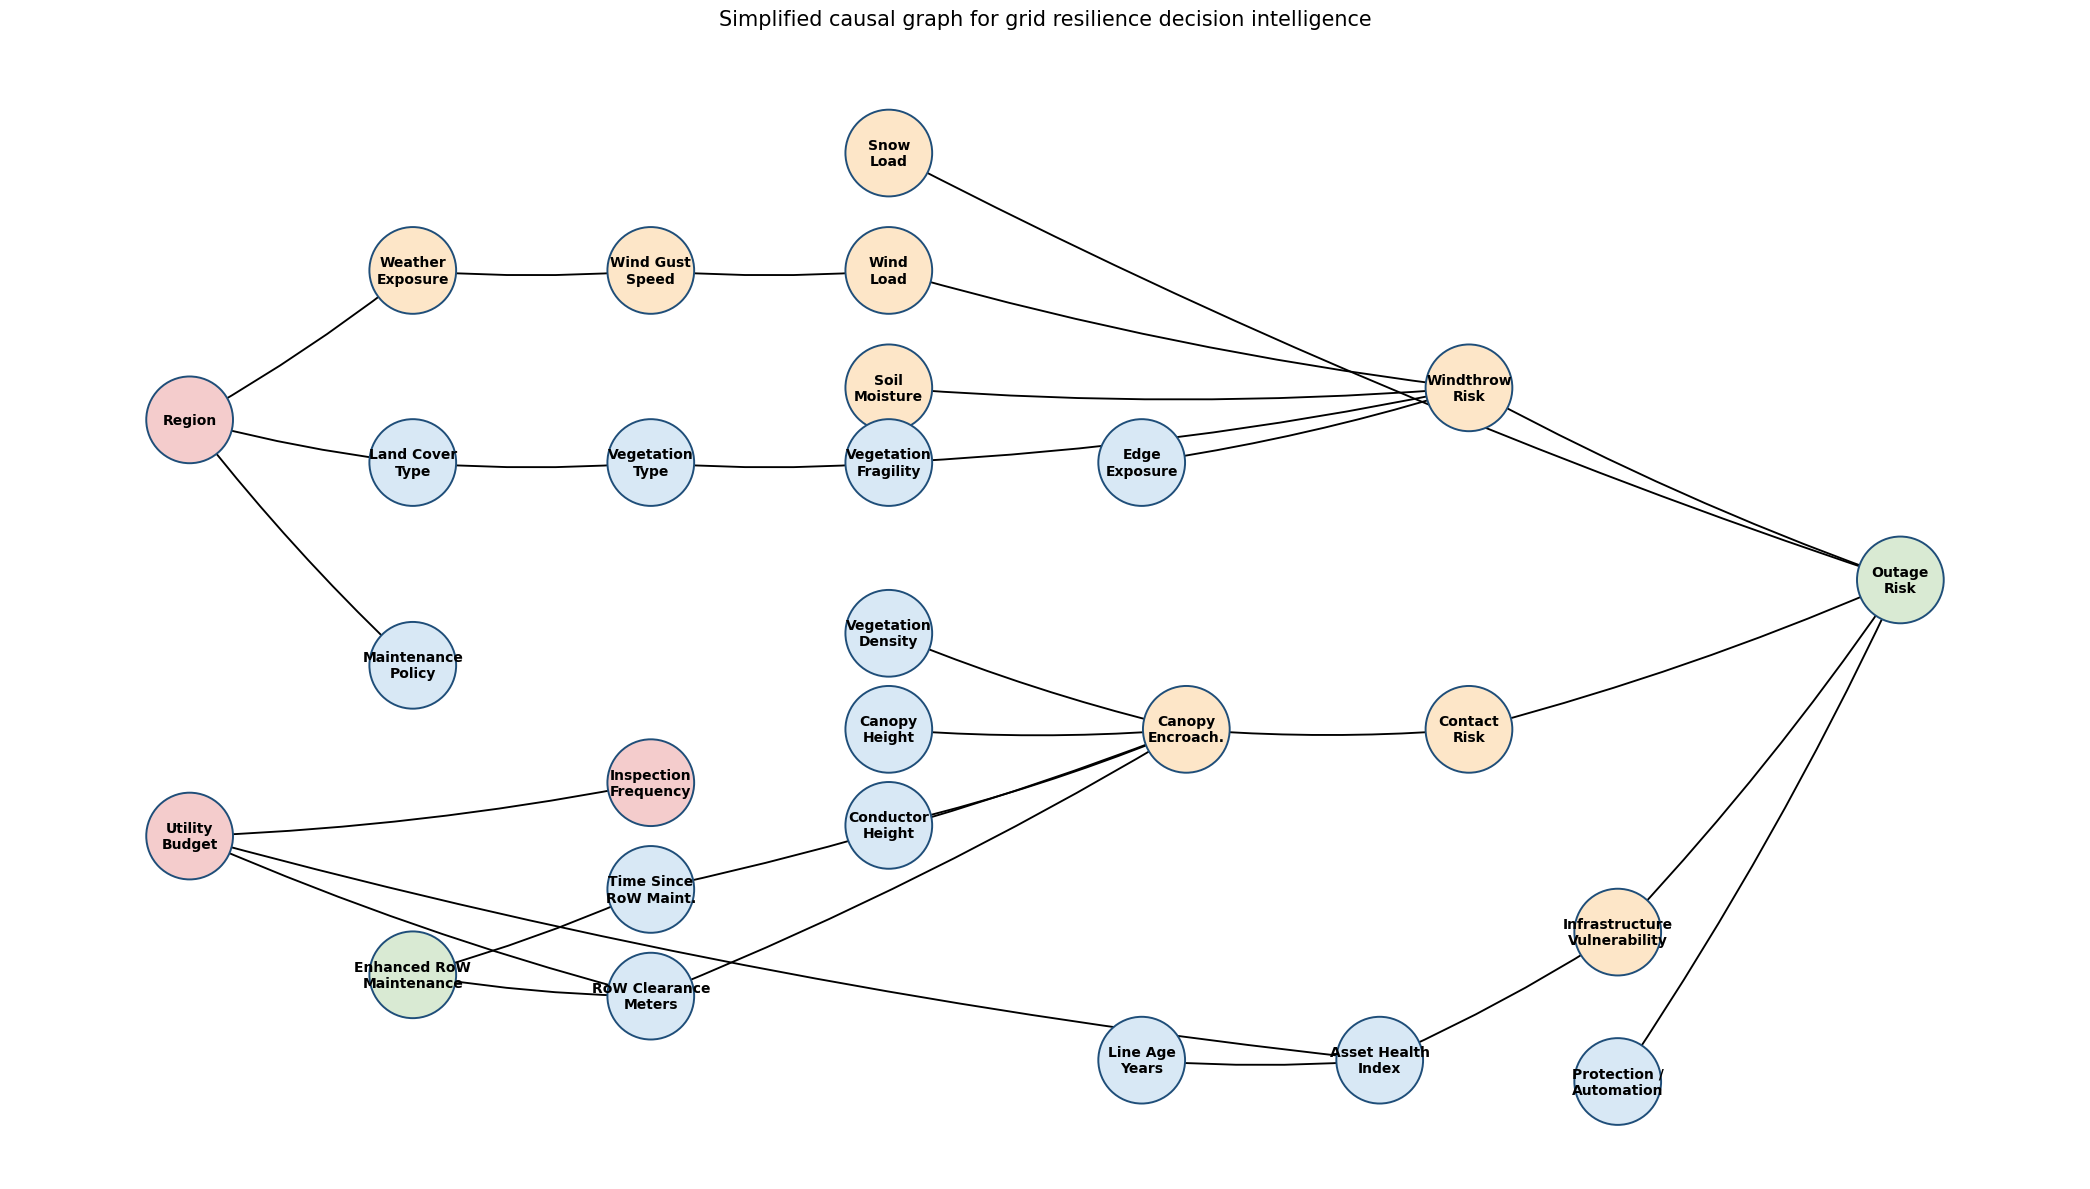

In [7]:
# Readable causal graph for the Grid Resilience SCM
# This version uses shorter/wrapped labels, larger spacing, and larger node-label fonts.

import textwrap
import matplotlib.pyplot as plt
import networkx as nx

def wrap_label(label, width=14):
    """Wrap long node labels onto multiple lines."""
    return "\n".join(textwrap.wrap(label, width=width))


def draw_dag_readable(edges, pos, title, node_colors=None, figsize=(20, 11), font_size=10):
    """Draw a readable DAG with wrapped labels and larger spacing."""
    G = nx.DiGraph()
    G.add_edges_from(edges)

    node_colors = node_colors or {node: COLORS["light_blue"] for node in G.nodes()}
    colors = [node_colors.get(node, COLORS["light_blue"]) for node in G.nodes()]

    label_map = {
        "Region": "Region",
        "UtilityBudget": "Utility\nBudget",
        "WeatherExposure": "Weather\nExposure",
        "LandCoverType": "Land Cover\nType",
        "MaintenancePolicy": "Maintenance\nPolicy",
        "InspectionFrequency": "Inspection\nFrequency",
        "WindGustSpeed": "Wind Gust\nSpeed",
        "WindLoad": "Wind\nLoad",
        "SnowLoad": "Snow\nLoad",
        "SoilMoisture": "Soil\nMoisture",
        "VegetationType": "Vegetation\nType",
        "VegetationFragility": "Vegetation\nFragility",
        "VegetationDensity": "Vegetation\nDensity",
        "CanopyHeight": "Canopy\nHeight",
        "TimeSinceRoWMaintenance": "Time Since\nRoW Maint.",
        "RoWClearanceMeters": "RoW Clearance\nMeters",
        "ConductorHeight": "Conductor\nHeight",
        "CanopyEncroachment": "Canopy\nEncroach.",
        "ContactRisk": "Contact\nRisk",
        "WindthrowRisk": "Windthrow\nRisk",
        "LineAgeYears": "Line Age\nYears",
        "AssetHealthIndex": "Asset Health\nIndex",
        "InfrastructureVulnerability": "Infrastructure\nVulnerability",
        "ProtectionAutomation": "Protection /\nAutomation",
        "EnhancedRoWMaintenance": "Enhanced RoW\nMaintenance",
        "EdgeExposure": "Edge\nExposure",
        "OutageRisk": "Outage\nRisk",
    }

    labels = {node: label_map.get(node, wrap_label(node)) for node in G.nodes()}

    plt.figure(figsize=figsize)

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=colors,
        node_size=3900,
        edgecolors=COLORS["navy"],
        linewidths=1.4
    )

    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowsize=17,
        width=1.35,
        edge_color="black",
        connectionstyle="arc3,rad=0.04",
        min_source_margin=15,
        min_target_margin=15
    )

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=font_size,
        font_weight="bold",
        font_family="DejaVu Sans"
    )

    plt.title(title, fontsize=15, pad=22)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return G


edges = [
    ("Region", "WeatherExposure"),
    ("Region", "LandCoverType"),
    ("Region", "MaintenancePolicy"),
    ("UtilityBudget", "InspectionFrequency"),
    ("UtilityBudget", "RoWClearanceMeters"),
    ("UtilityBudget", "AssetHealthIndex"),
    ("WeatherExposure", "WindGustSpeed"),
    ("WindGustSpeed", "WindLoad"),
    ("SnowLoad", "OutageRisk"),
    ("SoilMoisture", "WindthrowRisk"),
    ("LandCoverType", "VegetationType"),
    ("VegetationType", "VegetationFragility"),
    ("VegetationDensity", "CanopyEncroachment"),
    ("CanopyHeight", "CanopyEncroachment"),
    ("TimeSinceRoWMaintenance", "CanopyEncroachment"),
    ("RoWClearanceMeters", "CanopyEncroachment"),
    ("ConductorHeight", "CanopyEncroachment"),
    ("CanopyEncroachment", "ContactRisk"),
    ("WindLoad", "WindthrowRisk"),
    ("VegetationFragility", "WindthrowRisk"),
    ("EdgeExposure", "WindthrowRisk"),
    ("LineAgeYears", "AssetHealthIndex"),
    ("AssetHealthIndex", "InfrastructureVulnerability"),
    ("ProtectionAutomation", "OutageRisk"),
    ("ContactRisk", "OutageRisk"),
    ("WindthrowRisk", "OutageRisk"),
    ("InfrastructureVulnerability", "OutageRisk"),
    ("EnhancedRoWMaintenance", "RoWClearanceMeters"),
    ("EnhancedRoWMaintenance", "TimeSinceRoWMaintenance"),
]

# Wider and more separated layout
pos = {
    # Context and hidden/proxy factors
    "Region": (-6.3, 1.6),
    "UtilityBudget": (-6.3, -2.3),

    # Weather pathway
    "WeatherExposure": (-4.8, 3.0),
    "WindGustSpeed": (-3.2, 3.0),
    "WindLoad": (-1.6, 3.0),
    "SnowLoad": (-1.6, 4.1),
    "SoilMoisture": (-1.6, 1.9),

    # Land cover and vegetation pathway
    "LandCoverType": (-4.8, 1.2),
    "VegetationType": (-3.2, 1.2),
    "VegetationFragility": (-1.6, 1.2),
    "EdgeExposure": (0.1, 1.2),

    # Maintenance and vegetation proximity pathway
    "MaintenancePolicy": (-4.8, -0.7),
    "InspectionFrequency": (-3.2, -1.8),
    "EnhancedRoWMaintenance": (-4.8, -3.6),
    "TimeSinceRoWMaintenance": (-3.2, -2.8),
    "RoWClearanceMeters": (-3.2, -3.8),

    "VegetationDensity": (-1.6, -0.4),
    "CanopyHeight": (-1.6, -1.3),
    "ConductorHeight": (-1.6, -2.2),
    "CanopyEncroachment": (0.4, -1.3),
    "ContactRisk": (2.3, -1.3),

    # Infrastructure pathway
    "LineAgeYears": (0.1, -4.4),
    "AssetHealthIndex": (1.7, -4.4),
    "InfrastructureVulnerability": (3.3, -3.2),
    "ProtectionAutomation": (3.3, -4.6),

    # Intermediate and final outcome
    "WindthrowRisk": (2.3, 1.9),
    "OutageRisk": (5.2, 0.1),
}

node_colors = {}
for node in pos:
    if node in ["EnhancedRoWMaintenance", "OutageRisk"]:
        node_colors[node] = COLORS["light_green"]
    elif node in ["UtilityBudget", "InspectionFrequency", "Region"]:
        node_colors[node] = COLORS["light_red"]
    elif node in [
        "WeatherExposure", "WindGustSpeed", "WindLoad", "SnowLoad", "SoilMoisture",
        "CanopyEncroachment", "ContactRisk", "WindthrowRisk", "InfrastructureVulnerability"
    ]:
        node_colors[node] = COLORS["light_orange"]
    else:
        node_colors[node] = COLORS["light_blue"]

G_grid = draw_dag_readable(
    edges=edges,
    pos=pos,
    title="Simplified causal graph for grid resilience decision intelligence",
    node_colors=node_colors,
    figsize=(21, 12),
    font_size=10
)

### Interpretation

The graph summarizes the assumed causal structure behind the Grid Resilience example. It is not a graph learned automatically from data. It is a transparent statement of how we believe vegetation-related outage risk is generated.

The node colors are used only as visual teaching aids:

- **Light red** nodes indicate broad contextual or hidden/proxy factors, such as `Region` and `UtilityBudget`.
- **Light blue** nodes indicate observed background variables, such as weather, vegetation, infrastructure, and maintenance-related variables.
- **Light orange** nodes indicate intermediate risk mechanisms, such as `WindLoad`, `ContactRisk`, `WindthrowRisk`, and `InfrastructureVulnerability`.
- **Light green** nodes indicate the main intervention and outcome variables, such as `EnhancedRoWMaintenance` and `OutageRisk`.

The colors do not represent statistical significance, causal strength, or confidence in the edges. They are used only to make the causal roles easier to read.

The graph shows why `Region` can be a dangerous predictive shortcut. Region may be associated with weather exposure, land-cover type, maintenance policy, utility budget, vegetation conditions, and asset characteristics. Therefore, a predictive model may learn that some regions historically have higher outage risk.

However, `Region` itself is not the main causal mechanism and is not directly actionable. A utility cannot reduce outage risk by simply “changing the region” of a power line or moving the same infrastructure to another region. Instead, it can act on operational and engineering mechanisms such as right-of-way clearance, time since maintenance, inspection strategy, asset health, protection and automation, and vegetation proximity to conductors.

The graph also separates different types of causal drivers:

- **Hazard drivers**, such as wind load, snow load, and soil moisture.
- **Vegetation drivers**, such as vegetation type, vegetation density, canopy height, canopy encroachment, and vegetation fragility.
- **Infrastructure drivers**, such as conductor height, line age, asset health, and infrastructure vulnerability.
- **Maintenance and policy drivers**, such as utility budget, inspection frequency, right-of-way clearance, and enhanced maintenance.

These mechanisms feed into intermediate risk variables such as `ContactRisk`, `WindthrowRisk`, and `InfrastructureVulnerability`, which then influence `OutageRisk`.

The key teaching point is:

> Predictive models may use proxy variables such as `Region`, while causal decision-making should focus on mechanisms that can be monitored, explained, and changed.

This graph therefore connects the three themes of the chapter:

- **Robustness:** mechanism-based relationships are more likely to remain meaningful under environment shift.
- **Explainability:** causal explanations identify why outage risk is high.
- **Adaptivity:** the system can monitor whether maintenance, vegetation, and infrastructure mechanisms change after deployment.

</br>

---
## 7. Robustness: Random Split vs. Environment Split

We now compare two types of models to study **robustness** under deployment shift.

### Model 1: shortcut predictive model

The first model uses variables that may be useful for prediction in the historical data, but may not remain stable after deployment:

- `Region`
- `HistoricalOutageRate`
- `InspectionFrequency`
- `VegetationDensity`
- `WindGustSpeed`

These variables can capture historical patterns. For example, some regions may have had higher outage rates in the past, or inspection frequency may be associated with better maintenance capacity. However, these relationships can change when a new policy is introduced or when the model is deployed in a new region.

### Model 2: mechanism-informed model

The second model uses variables that are closer to physical and operational mechanisms:

- weather exposure,
- vegetation type and structure,
- right-of-way clearance,
- time since maintenance,
- infrastructure characteristics,
- asset health,
- terrain exposure.

These variables are not guaranteed to make the model perfect. However, they are more directly connected to the mechanisms that generate outage risk.

The purpose of this comparison is not to claim that the mechanism-informed model is always better. The purpose is to show a central robustness lesson:

> A model that relies on unstable proxies can look strong under random validation but fail under deployment shift.

A random train-test split asks whether the model predicts well for data drawn from the same historical environment. An environment split asks a harder and more realistic question:

> Does the model still work when the policy, geography, or operating conditions change?

The next code cell trains both models on historical data and evaluates them under three settings:

1. a random split within the historical environment,
2. deployment under the new maintenance policy, and
3. deployment in a new region.

In [8]:
target = "OutageRiskScore"

shortcut_features = [
    "Region",
    "HistoricalOutageRate",
    "InspectionFrequency",
    "VegetationDensity",
    "WindGustSpeed"
]

mechanism_features = [
    "WindGustSpeed",
    "SnowLoad",
    "SoilMoisture",
    "TerrainExposure",
    "LandCoverType",
    "VegetationType",
    "VegetationDensity",
    "CanopyHeight",
    "CanopyEncroachment",
    "EdgeExposure",
    "RoWClearanceMeters",
    "TimeSinceRoWMaintenance",
    "VoltageLevel",
    "LineType",
    "PoleHeight",
    "ConductorHeight",
    "LineAgeYears",
    "AssetHealthIndex",
    "ProtectionAutomation",
]

hist_train, hist_test = train_test_split(historical, test_size=0.30, random_state=42)

shortcut_model = fit_rf_model(hist_train, shortcut_features, target, seed=42)
mechanism_model = fit_rf_model(hist_train, mechanism_features, target, seed=42)

eval_sets = {
    "Historical random test": hist_test,
    "New policy": new_policy,
    "New region": new_region,
}

rows = []
for model_name, model, features in [
    ("Shortcut model", shortcut_model, shortcut_features),
    ("Mechanism-informed model", mechanism_model, mechanism_features),
]:
    for env_name, df_eval in eval_sets.items():
        metrics = evaluate_model(model, df_eval, features, target)
        rows.append({
            "Model": model_name,
            "Evaluation environment": env_name,
            "RMSE": metrics["RMSE"],
            "R2": metrics["R2"]
        })

performance = pd.DataFrame(rows)
display_df(performance)

,Model,Evaluation environment,RMSE,R2
0,Shortcut model,Historical random test,0.096,0.633
1,Shortcut model,New policy,0.093,0.645
2,Shortcut model,New region,0.107,0.557
3,Mechanism-informed model,Historical random test,0.043,0.926
4,Mechanism-informed model,New policy,0.052,0.887
5,Mechanism-informed model,New region,0.048,0.912


The next code cell visualizes the model-performance results as a heatmap.

Each cell shows two metrics:

- **RMSE**, where lower values mean better prediction accuracy.
- **R²**, where higher values mean better explained variation.

The heatmap compares the shortcut model and the mechanism-informed model across the historical random test set, the new policy environment, and the new region. This makes it easier to see whether a model is robust only under random validation or also under deployment shift.

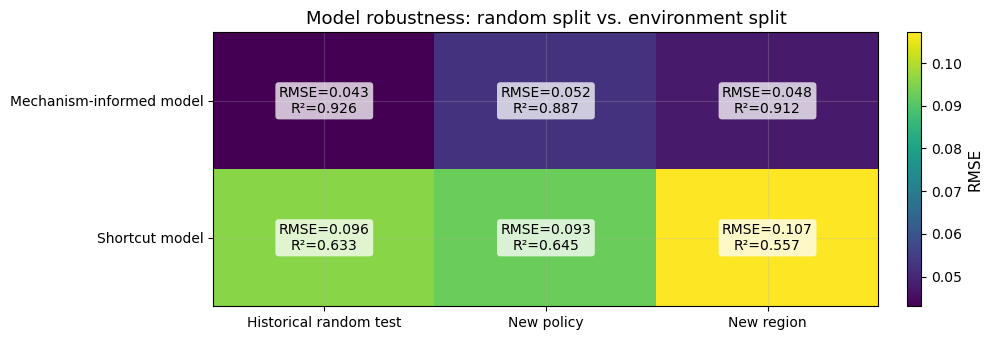

In [9]:
perf_matrix = performance.pivot(
    index="Model",
    columns="Evaluation environment",
    values="RMSE"
)
perf_matrix = perf_matrix[["Historical random test", "New policy", "New region"]]

fig, ax = plt.subplots(figsize=(10, 3.5))
im = ax.imshow(perf_matrix.values, aspect="auto")

ax.set_xticks(np.arange(perf_matrix.shape[1]))
ax.set_yticks(np.arange(perf_matrix.shape[0]))
ax.set_xticklabels(perf_matrix.columns)
ax.set_yticklabels(perf_matrix.index)

for i in range(perf_matrix.shape[0]):
    for j in range(perf_matrix.shape[1]):
        model = perf_matrix.index[i]
        env = perf_matrix.columns[j]
        rmse_val = perf_matrix.iloc[i, j]
        r2_val = performance.loc[
            (performance["Model"] == model) &
            (performance["Evaluation environment"] == env),
            "R2"
        ].iloc[0]

        ax.text(
            j, i,
            f"RMSE={rmse_val:.3f}\nR²={r2_val:.3f}",
            ha="center",
            va="center",
            fontsize=10,
            color="black",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="none",
                alpha=0.75
            )
        )

ax.set_title("Model robustness: random split vs. environment split")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="RMSE")
plt.tight_layout()
plt.show()

### Interpretation

The table and heatmap compare how the two models perform under random validation and under deployment shift.

The **shortcut model** performs reasonably well in the historical random test set, with **RMSE = 0.096** and **R² = 0.634**. However, its performance becomes weaker in the `NewRegion` environment, where **RMSE increases to 0.107** and **R² drops to 0.557**. This suggests that some historical patterns learned by the shortcut model do not transfer well to a new geographical and operational context.

The **mechanism-informed model** performs better across all environments. In the `NewRegion` environment, its **RMSE = 0.047** and **R² = 0.913**, compared with **RMSE = 0.107** and **R² = 0.557** for the shortcut model.

This result illustrates the main robustness lesson of the chapter:

> A model that relies on mechanism-related variables is more likely to remain useful when the deployment environment changes.

The random split answers a limited question:

$$E[\text{error} \mid \text{train and test are mixed from the same historical environment}]$$

The environment split asks a harder and more realistic question:

$$E[\text{error} \mid \text{test environment differs from training environment}]$$

The key point is not that mechanism-informed models will always outperform shortcut models. The key point is that random train-test validation can hide deployment risk. For deployed AI systems, robustness should therefore be evaluated under meaningful environment shifts, not only under random train-test splits.


</br>

---
## 8. Spurious Shortcuts and Predictive Explanations

After evaluating robustness, we now ask why a model performs the way it does.

A common first step is to inspect **feature importance**. Feature importance tells us which variables were useful for prediction in a fitted model. However, it does not tell us whether those variables are true causes of the outcome.

This distinction is important:

> Feature importance explains the model’s prediction behavior.  
> Causal explanation explains the system that generated the outcome.

In the Grid Resilience example, variables such as `Region`, `HistoricalOutageRate`, and `InspectionFrequency` can be useful for predicting historical outage risk. But they are not necessarily direct causes of outage risk, and they may become unreliable after policy, climate, maintenance, or regional changes.

For example, `Region` may summarize many hidden differences, such as weather exposure, land-cover type, vegetation type, utility budget, maintenance policy, and infrastructure age. A model may therefore learn that some regions historically had higher outage risk.

However, `Region` itself is usually not a realistic intervention target. In practice, a utility cannot reduce outage risk by simply moving an existing power line to another region. The location of a power line is fixed by geography, settlements, substations, demand centers, permits, and infrastructure planning. Instead, the utility must manage risk within that region by acting on operational and engineering mechanisms such as right-of-way clearance, canopy encroachment, inspection strategy, asset health, pole or conductor upgrades, protection automation, and targeted vegetation management before storm season.

The causal lesson is:

> `Region` may help predict risk, but actionable causal explanations should point to mechanisms that can actually be changed.

This section separates two types of explanation:

| Explanation type | Main question | Example |
|---|---|---|
| Predictive explanation | Which variables helped the model predict? | `Region` was important for the model |
| Causal explanation | Which mechanisms could change the outcome? | Increasing right-of-way clearance may reduce outage risk |

Relevant recent references: [Explainable artificial intelligence: A survey of needs, techniques, applications, and future direction (2024)](https://www.sciencedirect.com/science/article/abs/pii/S0925231224008828), [The role of causality in explainable artificial intelligence (2025)](https://wires.onlinelibrary.wiley.com/doi/10.1002/widm.70015), and [Position: Explainable AI is Causality in Disguise (2026)](https://arxiv.org/abs/2603.28597).


The next code cell compares predictive feature importance for the two models.

The goal is not to treat feature importance as causal evidence. The goal is to inspect whether the models rely mainly on broad historical proxies, such as `Region` or `HistoricalOutageRate`, or on more mechanism-related variables, such as wind exposure, canopy encroachment, clearance, and asset health.


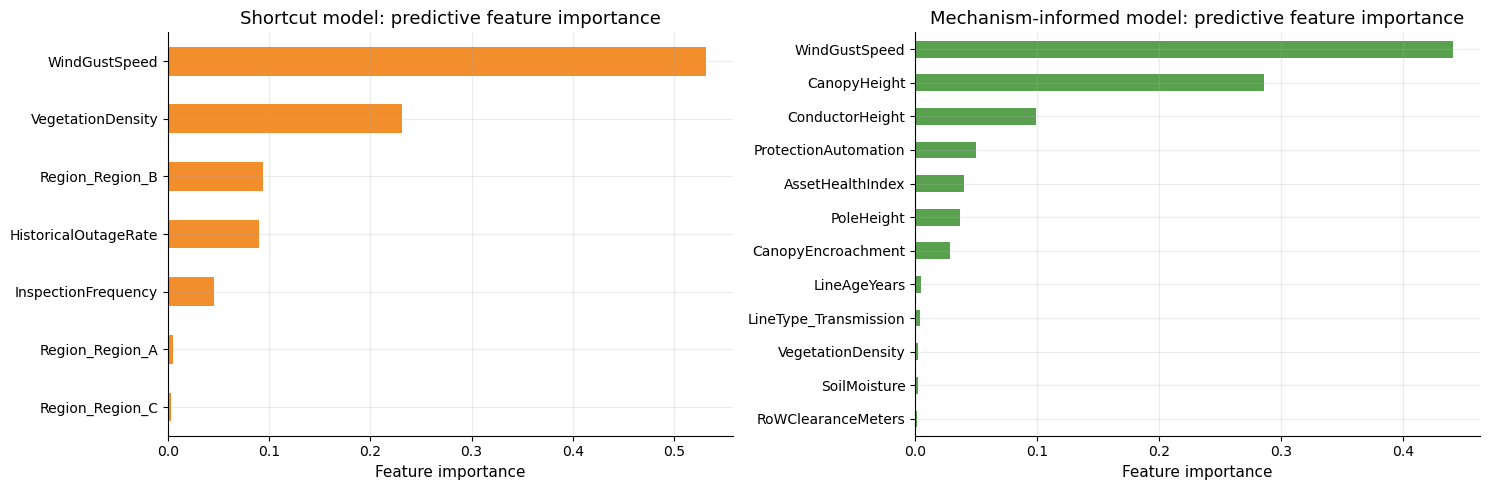

In [10]:
def get_feature_importance(model, features, train_df):
    """Extract feature importance from a pipeline with OneHotEncoder and RandomForestRegressor."""
    preprocessor = model.named_steps["preprocess"]
    rf = model.named_steps["rf"]

    categorical_features = [c for c in features if train_df[c].dtype == "object"]
    numeric_features = [c for c in features if c not in categorical_features]

    feature_names = []
    if len(categorical_features) > 0:
        ohe = preprocessor.named_transformers_["cat"]
        feature_names.extend(ohe.get_feature_names_out(categorical_features).tolist())
    feature_names.extend(numeric_features)

    return pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)

shortcut_importance = get_feature_importance(shortcut_model, shortcut_features, hist_train)
mechanism_importance = get_feature_importance(mechanism_model, mechanism_features, hist_train)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

shortcut_importance.tail(12).plot(kind="barh", ax=axes[0], color=COLORS["orange"])
axes[0].set_title("Shortcut model: predictive feature importance")
axes[0].set_xlabel("Feature importance")
clean_axis(axes[0])

mechanism_importance.tail(12).plot(kind="barh", ax=axes[1], color=COLORS["green"])
axes[1].set_title("Mechanism-informed model: predictive feature importance")
axes[1].set_xlabel("Feature importance")
clean_axis(axes[1])

plt.tight_layout()
plt.show()

### Interpretation

The feature-importance plots show what each model used for prediction.

The **shortcut model** uses a mixture of meaningful variables and broad historical proxies. Such variables can be predictive in historical data but may become unreliable after policy, climate, maintenance, or regional changes.

The **mechanism-informed model** relies more on variables connected to physical and operational mechanisms, such as `WindGustSpeed`, `CanopyHeight`, `ConductorHeight`, `ProtectionAutomation`, and `AssetHealthIndex`.

The table below summarizes the key distinction between predictive explanation and causal explanation.

> Predictive explanation explains the model. Causal explanation explains the system and supports action.

| Predictive feature | Why it may predict | Is it directly actionable? | Causal interpretation |
|---|---|---|---|
| `Region` | Proxy for weather, land cover, maintenance, and assets | No | Not a direct intervention target |
| `HistoricalOutageRate` | Summarizes past risk | No | May encode outdated policy and climate conditions |
| `InspectionFrequency` | Related to utility budget and monitoring effort | Partly | Confounded by maintenance capacity |
| `CanopyEncroachment` | Directly related to contact risk | Yes | Actionable vegetation mechanism |
| `RoWClearanceMeters` | Reduces contact and encroachment risk | Yes | Intervention-relevant mechanism |
| `AssetHealthIndex` | Captures infrastructure vulnerability | Yes | Upgrade or maintenance target |


</br>

---
## 9. Actionable Causal Explanations and Heterogeneous Intervention Effects

A useful explanation should not only describe why the model predicted high risk. It should also help decision makers understand what can be changed.

In this example, the actionable intervention is **enhanced right-of-way maintenance** before storm season. This may include targeted trimming, wider clearance, or more recent vegetation management near power-line corridors.

We define the treatment as:

$$T = 1$$

enhanced right-of-way maintenance before storm season

$$T = 0$$

normal maintenance

For each line segment $i$, the individual treatment effect is:

$$\tau_i = Y_i(1) - Y_i(0)$$

where:

- $Y_i(1)$ is the outage risk if line segment $i$ receives enhanced maintenance;
- $Y_i(0)$ is the outage risk if line segment $i$ receives normal maintenance.

Because the outcome is outage risk, lower values are better. Therefore:

$$\tau_i < 0$$

means that enhanced maintenance reduces outage risk for line segment $i$.

The average treatment effect tells us the average benefit of enhanced maintenance across all line segments. However, this average can hide important differences. Some line segments may benefit much more than others.

To study this heterogeneity, we use the Conditional Average Treatment Effect:

$$CATE(x) = E[Y(1) - Y(0) \mid X = x]$$

This asks:

> *Which types of line segments benefit most from enhanced maintenance?*

For example, enhanced maintenance may have a larger effect for line segments with high wind exposure, high canopy encroachment, fragile vegetation, low conductor height, or lower asset health.

In a real utility dataset, we would not observe both $Y_i(1)$ and $Y_i(0)$ for the same line segment. We would only observe the outcome under the maintenance decision that actually happened. In this synthetic teaching example, both potential outcomes are available because we generated the data from an SCM. We use this information only for teaching, evaluation, and visualization.

The goal of this section is to move from explanation to decision support:

> Prediction tells us where outage risk is high.  
> Causal effect estimation helps us decide where maintenance is expected to reduce risk the most.

Relevant recent references: [Causal machine learning for heterogeneous treatment effects with missing outcome data (2025)](https://academic.oup.com/biometrics/article/81/3/ujaf098/8220015), [Heterogeneous treatment effect estimation with high-dimensional data in policy evaluation (2024)](https://arxiv.org/abs/2401.07075), and [Combining T-learning and DR-learning for causal contrasts (2024)](https://arxiv.org/abs/2402.01972).

---
### A Simple X-learner for Intervention Benefit

To estimate which line segments benefit most from enhanced right-of-way maintenance, we use a simple **X-learner**.

We use the X-learner because enhanced maintenance is not randomly assigned in this example. Higher-risk line segments may be more likely to receive maintenance, so the treated and untreated groups may differ before the intervention. The X-learner is useful in this situation because it stays close to the potential-outcomes framework while providing a practical way to estimate heterogeneous treatment effects.

The idea is:

1. Fit one outcome model for treated line segments and one outcome model for untreated line segments.
2. Use these models to estimate the missing counterfactual outcome for each observed segment.
3. Construct imputed treatment-effect examples for both treated and untreated segments.
4. Fit treatment-effect models using these imputed effects.
5. Combine the treatment-effect estimates using the estimated probability of receiving enhanced maintenance.

The estimated effect is interpreted as:

$$\hat{\tau}(x) = \hat{Y}(1 \mid X=x) - \hat{Y}(0 \mid X=x)$$

where:

- $\hat{Y}(1 \mid X=x)$ is the estimated outage risk under enhanced maintenance;
- $\hat{Y}(0 \mid X=x)$ is the estimated outage risk under normal maintenance.

Because the outcome is outage risk, negative values mean expected risk reduction:

$$\hat{\tau}(x) < 0$$

This means that enhanced right-of-way maintenance is expected to reduce outage risk for line segments with characteristics $X=x$.

The X-learner is simple enough to teach in this chapter, but still realistic enough to show how causal machine learning can support targeted maintenance decisions.

</br>

The next code cell implements the X-learner for the Grid Resilience example. It uses historical data to learn how enhanced right-of-way maintenance changes outage risk, then applies the learned treatment-effect model to line segments in the new region. The code reports both the estimated average effect and the estimated effect for a high-risk subgroup with high wind exposure and high canopy encroachment.

Because this is a synthetic dataset, we can compare the estimated effects with the true simulated effects. In real utility data, the true effects would not be directly observed.


In [11]:
# Simple X-learner for estimating heterogeneous intervention benefit
# Treatment: EnhancedRoWMaintenance
# Outcome: OutageRiskScore
# Interpretation: negative treatment effect means enhanced maintenance reduces outage risk.

# Features used for heterogeneous treatment-effect estimation
cate_features = [
    "WindGustSpeed",
    "SnowLoad",
    "SoilMoisture",
    "TerrainExposure",
    "LandCoverType",
    "VegetationType",
    "VegetationDensity",
    "CanopyHeight",
    "CanopyEncroachment",
    "EdgeExposure",
    "VoltageLevel",
    "LineType",
    "PoleHeight",
    "ConductorHeight",
    "LineAgeYears",
    "AssetHealthIndex",
    "ProtectionAutomation",
]

treatment_col = "EnhancedRoWMaintenance"
target = "OutageRiskScore"


def fit_rf_classifier(train_df, features, target, seed=42, n_estimators=80, min_samples_leaf=20):
    """Fit a random forest classifier with preprocessing for categorical and numerical features."""
    preprocessor, _, _ = make_preprocessor(train_df, features)
    model = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("rf", RandomForestClassifier(
                n_estimators=n_estimators,
                min_samples_leaf=min_samples_leaf,
                random_state=seed,
                n_jobs=1
            ))
        ]
    )
    model.fit(train_df[features], train_df[target])
    return model


# Training data from the historical environment
xlearner_train = historical.copy()

treated_train = xlearner_train[xlearner_train[treatment_col] == 1].copy()
untreated_train = xlearner_train[xlearner_train[treatment_col] == 0].copy()

# Step 1: fit outcome models
# m1 estimates E[Y | T=1, X=x]
# m0 estimates E[Y | T=0, X=x]
m1 = fit_rf_model(
    treated_train,
    cate_features,
    target,
    seed=201,
    n_estimators=80,
    min_samples_leaf=20
)

m0 = fit_rf_model(
    untreated_train,
    cate_features,
    target,
    seed=202,
    n_estimators=80,
    min_samples_leaf=20
)

# Step 2: impute treatment effects for observed treated and untreated units
# For treated units, observed outcome approximates Y(1), and m0 predicts missing Y(0)
treated_train["ImputedTreatmentEffect"] = (
    treated_train[target] - m0.predict(treated_train[cate_features])
)

# For untreated units, observed outcome approximates Y(0), and m1 predicts missing Y(1)
untreated_train["ImputedTreatmentEffect"] = (
    m1.predict(untreated_train[cate_features]) - untreated_train[target]
)

# Step 3: fit treatment-effect models
tau_model_treated = fit_rf_model(
    treated_train,
    cate_features,
    "ImputedTreatmentEffect",
    seed=203,
    n_estimators=80,
    min_samples_leaf=20
)

tau_model_untreated = fit_rf_model(
    untreated_train,
    cate_features,
    "ImputedTreatmentEffect",
    seed=204,
    n_estimators=80,
    min_samples_leaf=20
)

# Step 4: fit propensity model P(T=1 | X)
propensity_model = fit_rf_classifier(
    xlearner_train,
    cate_features,
    treatment_col,
    seed=205,
    n_estimators=80,
    min_samples_leaf=20
)

# Step 5: estimate treatment effects in the new region
decision_df = new_region.copy()

tau_hat_treated = tau_model_treated.predict(decision_df[cate_features])
tau_hat_untreated = tau_model_untreated.predict(decision_df[cate_features])
propensity_hat = propensity_model.predict_proba(decision_df[cate_features])[:, 1]

# X-learner combination.
# This weighted average combines treatment-effect estimates from both groups.
decision_df["EstimatedTreatmentEffect"] = (
    propensity_hat * tau_hat_untreated
    + (1 - propensity_hat) * tau_hat_treated
)

# Optional: estimated potential risks from outcome models
decision_df["EstimatedRisk_T1"] = m1.predict(decision_df[cate_features])
decision_df["EstimatedRisk_T0"] = m0.predict(decision_df[cate_features])

# Summary statistics
true_ate = decision_df["TrueTreatmentEffect"].mean()
estimated_ate = decision_df["EstimatedTreatmentEffect"].mean()

high_exposure = (
    (decision_df["WindGustSpeed"] > decision_df["WindGustSpeed"].quantile(0.75)) &
    (decision_df["CanopyEncroachment"] > decision_df["CanopyEncroachment"].quantile(0.75))
)

true_cate_high = decision_df.loc[high_exposure, "TrueTreatmentEffect"].mean()
estimated_cate_high = decision_df.loc[high_exposure, "EstimatedTreatmentEffect"].mean()

print(f"Number of treated line segments in historical data: {len(treated_train)}")
print(f"Number of untreated line segments in historical data: {len(untreated_train)}")
print()
print(f"True ATE in new region: {true_ate:.3f}")
print(f"Estimated ATE in new region: {estimated_ate:.3f}")
print()
print(f"True CATE for high wind + high encroachment: {true_cate_high:.3f}")
print(f"Estimated CATE for high wind + high encroachment: {estimated_cate_high:.3f}")


Number of treated line segments in historical data: 1164
Number of untreated line segments in historical data: 1036

True ATE in new region: -0.018
Estimated ATE in new region: -0.014

True CATE for high wind + high encroachment: -0.012
Estimated CATE for high wind + high encroachment: -0.004


The next code cell visualizes the estimated heterogeneous treatment effects.

Each point represents a line segment in the new region. The x-axis shows wind gust speed, and the y-axis shows the estimated effect of enhanced right-of-way maintenance on outage risk. Negative values mean that maintenance is expected to reduce risk.

The color shows asset health, and the point size reflects canopy encroachment. This helps us see which types of line segments are expected to benefit most from enhanced maintenance.

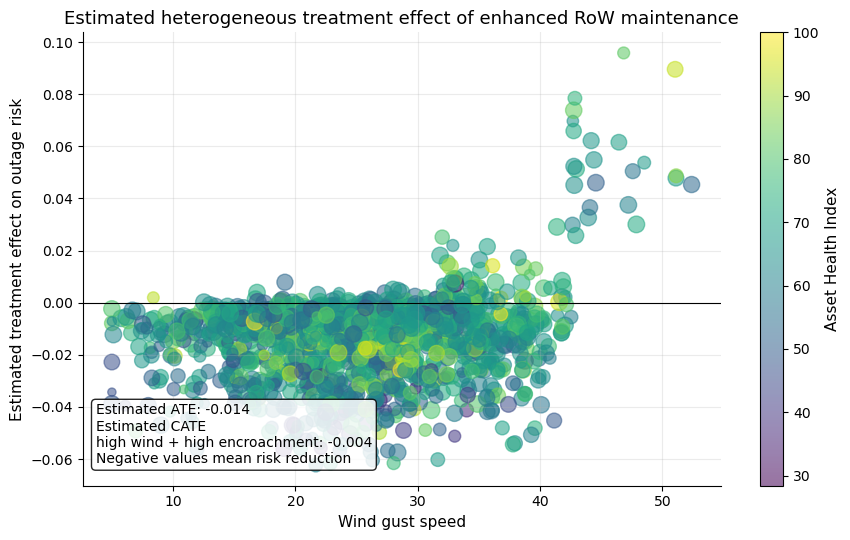

In [12]:
fig, ax = plt.subplots(figsize=(9, 5.5))

sizes = 30 + 120 * decision_df["CanopyEncroachment"]
scatter = ax.scatter(
    decision_df["WindGustSpeed"],
    decision_df["EstimatedTreatmentEffect"],
    c=decision_df["AssetHealthIndex"],
    s=sizes,
    alpha=0.55
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Estimated heterogeneous treatment effect of enhanced RoW maintenance")
ax.set_xlabel("Wind gust speed")
ax.set_ylabel("Estimated treatment effect on outage risk")
clean_axis(ax)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Asset Health Index")

text = (
    f"Estimated ATE: {estimated_ate:.3f}\n"
    f"Estimated CATE\nhigh wind + high encroachment: {estimated_cate_high:.3f}\n"
    "Negative values mean risk reduction"
)
ax.text(
    0.02, 0.05, text,
    transform=ax.transAxes,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    fontsize=10
)

plt.tight_layout()
plt.show()

### Interpretation

The X-learner estimates that enhanced right-of-way maintenance reduces outage risk on average in the new region.

The true simulated ATE is **-0.018**, while the estimated ATE is **-0.012**. Since both values are negative, the estimator correctly identifies the direction of the intervention effect. The magnitude is not exact, but it is reasonably close for a simple teaching method under deployment shift.

The estimated CATE for the high wind and high canopy-encroachment subgroup is close to zero. This means that the X-learner does not estimate a strong additional benefit for this subgroup beyond the average effect.

This result should not be interpreted as evidence that maintenance is useless for high-risk line segments. Instead, it suggests a more realistic operational interpretation: in very high-wind conditions, outage risk may be driven not only by direct vegetation encroachment, but also by windthrow, soil moisture, exposed forest edges, fragile vegetation, and infrastructure vulnerability. Standard right-of-way maintenance may reduce contact risk, but may not fully remove storm-driven outage risk.

The key lesson is:

> CATE estimation helps move from average intervention effects to targeted decision support, but the estimates must be interpreted together with domain knowledge, overlap, robustness, and deployment context.


</br>

---
## 10. Decision Intelligence Under a Limited Maintenance Budget

In real grid operations, the utility cannot maintain every line segment before storm season. Budgets, crews, equipment, permits, and time are limited.

Suppose the utility can perform enhanced right-of-way maintenance on only **20%** of line segments in the new region. The decision question is therefore not only:

> *Which line segments have the highest outage risk?*

but also:

> *Which line segments should be prioritized so that maintenance produces the largest expected risk reduction?*

These are related but different questions. A line segment may have high predicted outage risk, but maintenance may not reduce that risk much if the dominant mechanism is, for example, extreme wind exposure, weak infrastructure, or trees outside the maintained corridor.

We compare three allocation strategies:

1. **Random strategy:** maintain a random **20%** of line segments.
2. **Predictive risk strategy:** maintain the **20%** with the highest predicted outage risk.
3. **Causal benefit strategy:** maintain the **20%** with the largest estimated treatment benefit.

The key distinction is:

> Prediction tells us where risk is high.  
> Causality helps us estimate where intervention is expected to help most.

This section turns the causal analysis into a decision-support exercise. The goal is to show how causal intelligence can support operational prioritization under limited resources.

The next code cell creates and compares three maintenance-allocation strategies under the same budget constraint.

The utility can select only **20%** of line segments for enhanced right-of-way maintenance. The code selects segments using three rules:

1. random selection,
2. highest predicted outage risk from the shortcut model, and
3. largest estimated treatment benefit from the X-learner.

The code then compares the strategies using the true simulated avoidable risk. Because this is a synthetic dataset, we can calculate the true reduction in outage risk under enhanced maintenance. In real utility data, this quantity would need to be estimated rather than directly observed.

In [13]:
budget_fraction = 0.20
n_select = int(len(decision_df) * budget_fraction)

decision_df["ShortcutPredictedRisk"] = shortcut_model.predict(decision_df[shortcut_features])

rng = np.random.default_rng(123)
decision_df["Select_Random"] = 0
random_idx = rng.choice(decision_df.index, size=n_select, replace=False)
decision_df.loc[random_idx, "Select_Random"] = 1

decision_df["Select_PredictiveRisk"] = 0
pred_idx = decision_df.sort_values("ShortcutPredictedRisk", ascending=False).head(n_select).index
decision_df.loc[pred_idx, "Select_PredictiveRisk"] = 1

decision_df["Select_CausalBenefit"] = 0
causal_idx = decision_df.sort_values("EstimatedTreatmentEffect", ascending=True).head(n_select).index
decision_df.loc[causal_idx, "Select_CausalBenefit"] = 1

decision_df["TrueAvoidableRisk"] = (
    decision_df["RiskNoEnhancedMaintenance"] - decision_df["RiskEnhancedMaintenance"]
)

strategy_rows = []
for strategy, col in [
    ("Random maintenance", "Select_Random"),
    ("Predictive risk strategy", "Select_PredictiveRisk"),
    ("Causal benefit strategy", "Select_CausalBenefit"),
]:
    selected = decision_df[decision_df[col] == 1]
    strategy_rows.append({
        "Strategy": strategy,
        "Selected segments": len(selected),
        "Mean selected baseline risk": selected["RiskNoEnhancedMaintenance"].mean(),
        "Mean true avoidable risk": selected["TrueAvoidableRisk"].mean(),
        "Expected avoided outages per 1000 selected segments": 1000 * selected["TrueAvoidableRisk"].mean(),
        "Total expected avoided outages per 1000 all segments": 1000 * selected["TrueAvoidableRisk"].sum() / len(decision_df),
    })

strategy_summary = pd.DataFrame(strategy_rows)
display_df(strategy_summary)

,Strategy,Selected segments,Mean selected baseline risk,Mean true avoidable risk,Expected avoided outages per 1000 selected segments,Total expected avoided outages per 1000 all segments
0,Random maintenance,320,0.314,0.018,18.330,3.666
1,Predictive risk strategy,320,0.504,0.019,19.181,3.836
2,Causal benefit strategy,320,0.257,0.045,45.234,9.047


The next code cell visualizes the decision value of the three maintenance-allocation strategies.

The left plot compares the expected avoided outages under the same **20% maintenance budget**. This shows whether selecting line segments by estimated causal benefit produces more value than random selection or selection based only on predicted risk.

The right plot gives a simple map-like view of the line segments selected by the causal benefit strategy. The coordinates are synthetic, but the plot helps illustrate how a decision-support system could highlight which parts of the grid should be prioritized for enhanced maintenance.

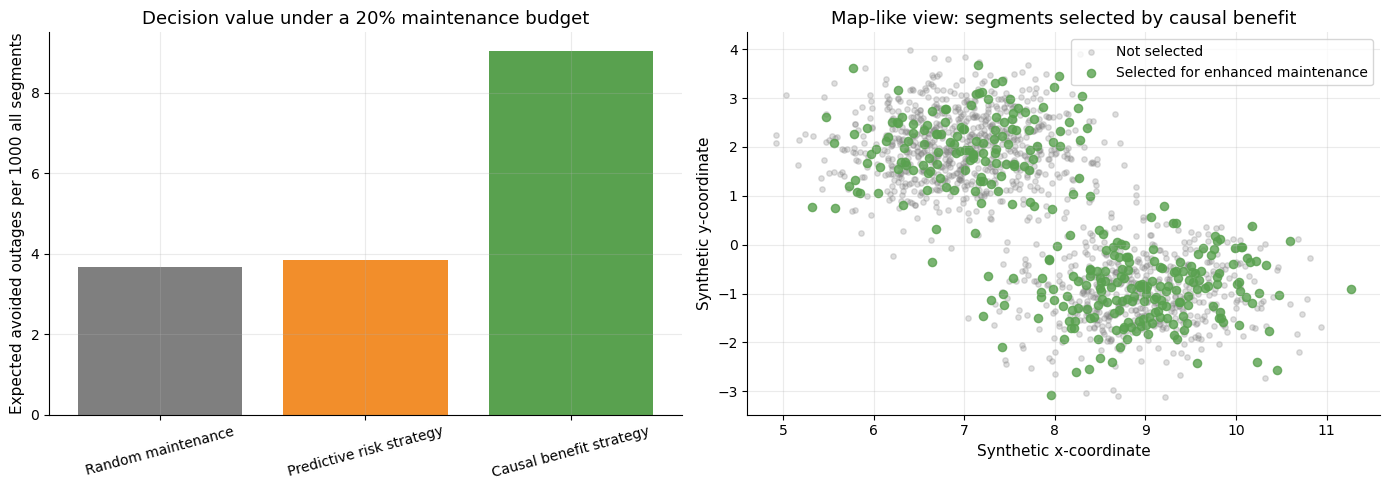

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    strategy_summary["Strategy"],
    strategy_summary["Total expected avoided outages per 1000 all segments"],
    color=[COLORS["gray"], COLORS["orange"], COLORS["green"]]
)
axes[0].set_title("Decision value under a 20% maintenance budget")
axes[0].set_ylabel("Expected avoided outages per 1000 all segments")
axes[0].tick_params(axis="x", rotation=15)
clean_axis(axes[0])

selected = decision_df["Select_CausalBenefit"] == 1
axes[1].scatter(
    decision_df.loc[~selected, "x_coord"],
    decision_df.loc[~selected, "y_coord"],
    s=15,
    alpha=0.25,
    color=COLORS["gray"],
    label="Not selected"
)
axes[1].scatter(
    decision_df.loc[selected, "x_coord"],
    decision_df.loc[selected, "y_coord"],
    s=35,
    alpha=0.80,
    color=COLORS["green"],
    label="Selected for enhanced maintenance"
)
axes[1].set_title("Map-like view: segments selected by causal benefit")
axes[1].set_xlabel("Synthetic x-coordinate")
axes[1].set_ylabel("Synthetic y-coordinate")
axes[1].legend()
clean_axis(axes[1])

plt.tight_layout()
plt.show()

### Interpretation

The left plot compares the decision value of the three strategies under the same **20% maintenance budget**.

- The **random maintenance** strategy gives the lowest expected benefit. This is expected because it does not use any information about risk or treatment benefit.

- The **predictive risk strategy** performs only slightly better than random selection. This means that selecting the highest-risk line segments is not necessarily the best maintenance strategy. Some high-risk segments may remain high risk even after maintenance if their risk is mainly driven by factors such as strong wind exposure, weak infrastructure, or regional conditions.

- The **causal benefit strategy** gives the largest expected reduction in outage risk. This strategy selects line segments where enhanced maintenance is estimated to make the biggest difference. In other words, it prioritizes intervention benefit rather than risk alone.

The right plot gives a simple map-like view of the line segments selected by the causal benefit strategy. The selected segments are not chosen randomly across the region. They cluster in parts of the synthetic grid where the model expects enhanced maintenance to reduce outage risk most.

The key lesson is:

> The highest-risk segments are not always the segments where maintenance creates the largest benefit.

This is the difference between predictive analytics and causal decision intelligence. Predictive analytics helps identify where risk is high. Causal decision intelligence helps identify where an intervention is expected to change the outcome.

</br>

The next code cell compares the three allocation strategies across different maintenance-budget levels.

Instead of fixing the budget at **20%**, the code varies the fraction of line segments that can receive enhanced maintenance, from small budgets to larger budgets. For each budget level, it calculates the total expected avoided outage risk under three strategies: random selection, predictive-risk selection, and causal-benefit selection.

The resulting gain curve shows how quickly each strategy accumulates avoided risk as the maintenance budget increases. A better prioritization strategy should achieve higher avoided risk with a smaller fraction of maintained segments.

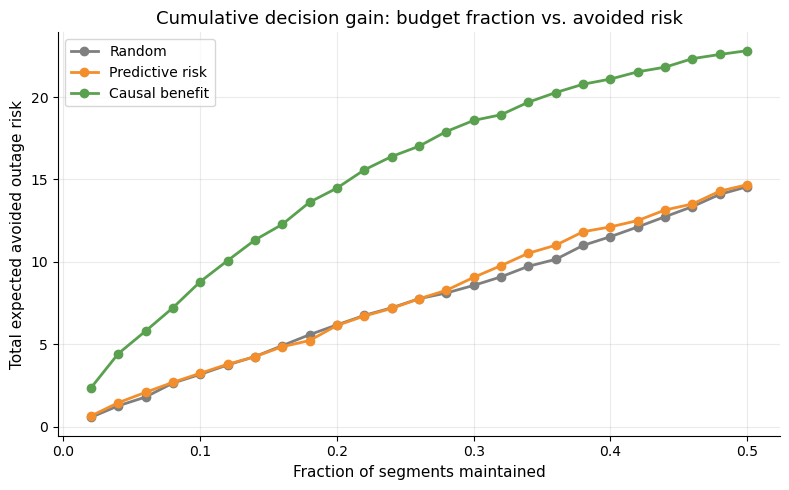

In [15]:
gain_df = decision_df.copy()
gain_df["RandomScore"] = rng.random(len(gain_df))
gain_df["PredictiveRiskScore"] = gain_df["ShortcutPredictedRisk"]
gain_df["CausalBenefitScore"] = -gain_df["EstimatedTreatmentEffect"]

fractions = np.linspace(0.02, 0.50, 25)
gain_rows = []

for frac in fractions:
    k = int(len(gain_df) * frac)
    for strategy, score_col in [
        ("Random", "RandomScore"),
        ("Predictive risk", "PredictiveRiskScore"),
        ("Causal benefit", "CausalBenefitScore"),
    ]:
        selected = gain_df.sort_values(score_col, ascending=False).head(k)
        gain_rows.append({
            "Budget fraction": frac,
            "Strategy": strategy,
            "Expected avoided risk": selected["TrueAvoidableRisk"].sum()
        })

gain_curve = pd.DataFrame(gain_rows)

fig, ax = plt.subplots(figsize=(8, 5))
for strategy, color in [
    ("Random", COLORS["gray"]),
    ("Predictive risk", COLORS["orange"]),
    ("Causal benefit", COLORS["green"])
]:
    part = gain_curve[gain_curve["Strategy"] == strategy]
    ax.plot(
        part["Budget fraction"],
        part["Expected avoided risk"],
        marker="o",
        linewidth=2,
        label=strategy,
        color=color
    )

ax.set_title("Cumulative decision gain: budget fraction vs. avoided risk")
ax.set_xlabel("Fraction of segments maintained")
ax.set_ylabel("Total expected avoided outage risk")
ax.legend()
clean_axis(ax)
plt.tight_layout()
plt.show()

### Interpretation

The gain curve extends the previous **20% maintenance-budget** result to many possible budget levels.

In the previous plot, we compared the three strategies at one fixed budget: maintaining **20%** of line segments. The causal benefit strategy produced the largest expected reduction in outage risk. This plot shows that the same pattern holds across a wider range of budgets.

The x-axis shows the fraction of line segments that receive enhanced maintenance. The y-axis shows the total expected avoided outage risk.

- The **random strategy** increases slowly because it does not prioritize line segments using risk or causal benefit information. It simply maintains randomly selected segments.

- The **predictive risk strategy** performs better than random in some parts of the curve, but it remains clearly below the causal benefit strategy. This means that selecting the highest-risk segments is useful, but not always optimal. Some high-risk segments may not be the most responsive to right-of-way maintenance.

- The **causal benefit strategy** has the steepest curve. This means it captures more avoidable risk with the same maintenance budget. In practical terms, it gives higher value when the utility has limited crews, time, and budget.

This connects directly to the previous result:

> At a fixed **20%** budget, the causal benefit strategy performed best.  
> Across many budget levels, it continues to accumulate avoided risk faster than the other strategies.

The key lesson is:

> Prediction helps identify where outages are likely.  
> Causal benefit estimation helps identify where maintenance is expected to change the outcome most.

For decision intelligence, the second question is often more useful.

</br>

---
## 11. Adaptivity: Monitoring Models, Mechanisms, and Interventions

Deployment is not a one-time event. Once an AI model is used in real operations, the system itself may begin to change. Maintenance policies may be updated, crews may act on model recommendations, vegetation conditions may evolve, weather patterns may shift, and new outage records may become available.

A causal AI system should therefore monitor more than prediction accuracy. It should also monitor whether the mechanisms behind the predictions remain plausible.

In the Grid Resilience example, an adaptive system should monitor five types of change:

| Monitoring target | Main question | Example in this chapter |
|---|---|---|
| **Prediction drift** | Is model error increasing over time? | The model becomes less accurate after deployment in a new region |
| **Distribution drift** | Are the input variables changing? | `CanopyEncroachment`, `RoWClearanceMeters`, or `WindGustSpeed` shift after a new policy or storm season |
| **Mechanism drift** | Are the relationships between causes and outcomes changing? | The link between vegetation, wind, and outage risk changes after new maintenance practices |
| **Intervention drift** | Does the intervention still work as expected? | Enhanced right-of-way maintenance may reduce risk less than before if windthrow becomes the dominant mechanism |
| **Proxy drift** | Are proxy variables becoming misleading? | `Region` may become less informative after maintenance policies change |

The key point is that adaptivity is not only about retraining the model. A purely predictive system may update its parameters when new data arrive. A causal AI system should also ask whether the assumed causal story still makes sense.

For example, after a new vegetation-management policy is introduced, the relationship between `Region` and outage risk may change. A model that previously used `Region` as a shortcut may become unreliable. At the same time, the relationship between right-of-way clearance, canopy encroachment, and outage risk should be monitored to see whether the intervention is actually reducing risk.

The adaptive question is therefore:

> Are the mechanisms and intervention effects we assumed during development still valid after deployment?

This is especially important in grid resilience because outage risk is affected by non-stationary conditions such as weather extremes, vegetation growth, maintenance actions, asset aging, and policy changes. Recent work on distribution-grid resilience emphasizes the need to quantify and visualize resilience under extreme weather using operational outage and weather data. Recent work on adaptive monitoring and OOD generalization also highlights the difficulty of keeping deployed AI models reliable under non-stationary conditions.

An adaptive causal AI system does not only update predictions. It updates its understanding of which mechanisms are stable, which proxies are becoming unreliable, and which interventions continue to work.

Relevant recent references: [Data-driven quantification and visualization of distribution-grid resilience to extreme weather events (2026)](https://www.nature.com/articles/s41598-026-37040-w), [Adaptive Monitoring for AI Deployments via Weighted Conformal Test Martingales (2025)](https://arxiv.org/abs/2505.04608), [Detecting and Remediating Harmful Data Shifts for the Responsible Deployment of Clinical AI Models (2025)](https://pmc.ncbi.nlm.nih.gov/articles/PMC12138723/), and [Out-of-distribution generalization in time series: A survey (2025)](https://arxiv.org/abs/2503.13868).


</br>

The next code cell gives a simple adaptivity diagnostic.

It compares model error across different deployment phases: historical validation, after the new maintenance policy, and in the new region. It also shows what happens when the mechanism-informed model is updated using both historical data and new policy data.

The goal is to illustrate that deployment should include monitoring and model updating, not only one-time model evaluation.

In [16]:
updated_train = pd.concat([historical, new_policy], ignore_index=True)

updated_mechanism_model = fit_rf_model(
    updated_train,
    mechanism_features,
    target,
    seed=202,
    n_estimators=80
)

adapt_rows = []

def add_adapt_row(phase, model_name, rmse_value):
    adapt_rows.append({
        "Deployment phase": phase,
        "Model": model_name,
        "RMSE": rmse_value
    })

add_adapt_row(
    "Historical validation",
    "Shortcut model",
    evaluate_model(shortcut_model, hist_test, shortcut_features, target)["RMSE"]
)
add_adapt_row(
    "Historical validation",
    "Mechanism model",
    evaluate_model(mechanism_model, hist_test, mechanism_features, target)["RMSE"]
)

add_adapt_row(
    "After policy change",
    "Shortcut model",
    evaluate_model(shortcut_model, new_policy, shortcut_features, target)["RMSE"]
)
add_adapt_row(
    "After policy change",
    "Mechanism model",
    evaluate_model(mechanism_model, new_policy, mechanism_features, target)["RMSE"]
)

add_adapt_row(
    "New region before update",
    "Shortcut model",
    evaluate_model(shortcut_model, new_region, shortcut_features, target)["RMSE"]
)
add_adapt_row(
    "New region before update",
    "Mechanism model",
    evaluate_model(mechanism_model, new_region, mechanism_features, target)["RMSE"]
)

add_adapt_row(
    "New region after update",
    "Updated mechanism model",
    evaluate_model(updated_mechanism_model, new_region, mechanism_features, target)["RMSE"]
)

adaptivity = pd.DataFrame(adapt_rows)
display_df(adaptivity)


,Deployment phase,Model,RMSE
0,Historical validation,Shortcut model,0.096
1,Historical validation,Mechanism model,0.043
2,After policy change,Shortcut model,0.093
3,After policy change,Mechanism model,0.052
4,New region before update,Shortcut model,0.107
5,New region before update,Mechanism model,0.048
6,New region after update,Updated mechanism model,0.041


### Interpretation

The table shows how model performance changes across deployment phases.

During **historical validation**, the mechanism-informed model has much lower error than the shortcut model:

- Shortcut RMSE: **0.096**
- Mechanism RMSE: **0.043**

This means the mechanism-informed model fits the historical test data better.

After the **new maintenance policy**, the shortcut model has **RMSE = 0.093**, while the mechanism-informed model has **RMSE = 0.052**. The mechanism-informed model still performs better, but its error increases slightly. This suggests that the new policy changed the data distribution, while the mechanism-based variables still remained useful.

In the **new region before update**, the shortcut model becomes weaker, with **RMSE = 0.107**. The mechanism-informed model remains much better, with **RMSE = 0.047**. This shows that the mechanism-informed model generalizes better under geographic deployment shift.

After updating the mechanism-informed model using both historical and new-policy data, the RMSE in the new region improves to **0.041**. This suggests that including more recent deployment data can improve performance.

The key lesson is:

> Adaptivity means monitoring model performance after deployment and updating the model when the environment changes.

However, the update should not be interpreted as automatic proof that the causal assumptions are correct. It shows improved prediction performance, but the system should still monitor whether the underlying mechanisms and intervention effects remain valid.


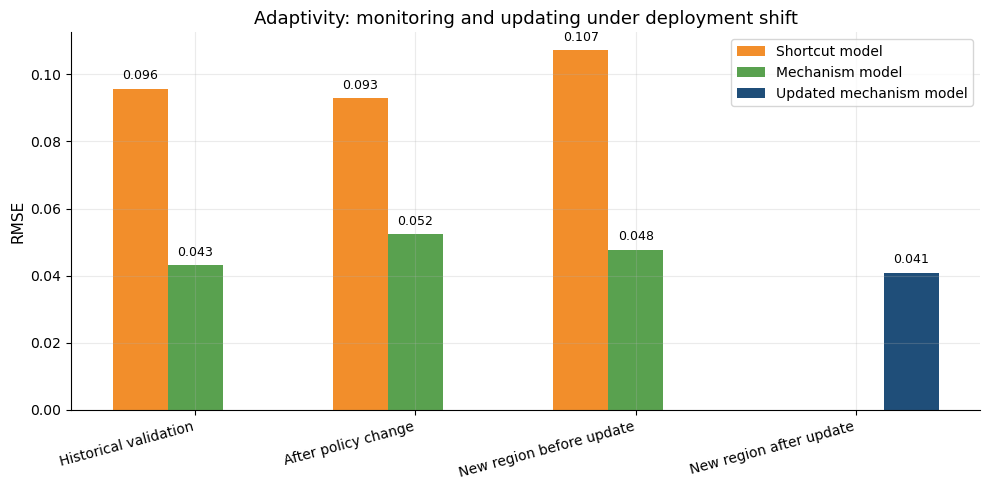

In [17]:
phase_order = [
    "Historical validation",
    "After policy change",
    "New region before update",
    "New region after update"
]
model_order = ["Shortcut model", "Mechanism model", "Updated mechanism model"]
model_colors = {
    "Shortcut model": COLORS["orange"],
    "Mechanism model": COLORS["green"],
    "Updated mechanism model": COLORS["navy"],
}

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(phase_order))
width = 0.25

for offset, model_name in zip([-width, 0, width], model_order):
    values = []
    for phase in phase_order:
        match = adaptivity[
            (adaptivity["Deployment phase"] == phase) &
            (adaptivity["Model"] == model_name)
        ]
        values.append(match["RMSE"].iloc[0] if len(match) else np.nan)

    bars = ax.bar(
        x + offset,
        values,
        width=width,
        label=model_name,
        color=model_colors[model_name]
    )

    for bar, value in zip(bars, values):
        if not np.isnan(value):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

ax.set_xticks(x)
ax.set_xticklabels(phase_order, rotation=15, ha="right")
ax.set_ylabel("RMSE")
ax.set_title("Adaptivity: monitoring and updating under deployment shift")
ax.legend()
clean_axis(ax)

plt.tight_layout()
plt.show()


### Interpretation

The bar chart visualizes how model error changes across deployment phases.

The **shortcut model** has the highest RMSE in the first three phases. This means it is less reliable than the mechanism-informed model, especially when the environment changes. Its error is highest in the **new region before update**, which suggests that historical shortcuts do not transfer well to a new geographic and operational setting.

The **mechanism-informed model** has consistently lower RMSE than the shortcut model. It performs well during historical validation and remains more stable after the policy change and in the new region. This supports the main robustness lesson: models based on physical and operational mechanisms tend to generalize better than models based mainly on historical proxies.

The **updated mechanism model** is shown in the final phase. It is trained after the system has observed both historical data and new-policy data, and then it is tested on the new region. Its RMSE is lower than the original mechanism model’s RMSE in the new region before update. This suggests that incorporating more recent deployment data can improve performance.

The key lesson is:

> Adaptivity means that deployment does not end with the first model. A causal AI system should monitor performance, detect environment changes, and update the model while continuing to check whether the underlying mechanisms and intervention effects remain valid.


</br>

---
## 12. Capstone Checklist for Causal AI Deployment

This checklist summarizes the main lesson of Chapter 5: moving from a predictive model to a causal AI decision system requires more than model accuracy.

A deployed causal AI system should define the decision, clarify the intervention, make causal assumptions visible, test robustness under environment shift, distinguish predictive explanations from causal explanations, estimate intervention benefits, and monitor whether the system remains valid after deployment.

| Step | Question | Output |
|---|---|---|
| 1. Define the decision | What operational decision will the model support? | Clear decision statement |
| 2. Define treatment and outcome | What action can be changed, and what outcome matters? | Unit, treatment $T$, outcome $Y$, and contrast |
| 3. Draw a causal graph | Which variables are causes, proxies, mediators, colliders, or outcomes? | Candidate DAG |
| 4. Identify shortcuts | Which features may work historically but fail under policy, region, or climate shift? | Proxy-risk list |
| 5. Check time order and actionability | Which variables are measured before the decision, and which can actually be changed? | Variable audit |
| 6. Test robustness | Does model performance hold across environments, not only under a random split? | Random-split vs. environment-split comparison |
| 7. Compare explanations | Are important features actionable mechanisms or only predictive signals? | Predictive vs. causal explanation table |
| 8. Estimate intervention benefit | Who benefits most from the action? | ATE, CATE, and subgroup effects |
| 9. Optimize decisions under constraints | How should limited resources be allocated? | Decision strategy or prioritization rule |
| 10. Monitor deployment | Are variables, model errors, mechanisms, and treatment effects drifting? | Monitoring dashboard |
| 11. Update carefully | Should the model, graph, or assumptions be revised using new deployment data? | Updated model and revised assumptions |
| 12. Report responsibly | What assumptions, limitations, and uncertainties remain? | Responsible causal interpretation |

In the Grid Resilience example, this checklist means that the utility should not only ask whether outage risk can be predicted. It should also ask which maintenance actions can reduce risk, whether the model remains reliable in new regions, whether explanations point to actionable mechanisms, and whether intervention effects remain stable after deployment.

This checklist connects Chapter 5 back to the entire course: causal questions, graphs, adjustment, causal machine learning, counterfactual reasoning, robustness checks, decision support, and responsible interpretation.

</br>

---
## 13. Chapter Summary

This chapter showed how causal intelligence can support AI systems after deployment.

The main focus was on three practical challenges: **robustness**, **explainability**, and **adaptivity**. These challenges become important when models are used in changing real-world environments, where historical correlations may no longer hold.

The Grid Resilience example illustrated these ideas using vegetation-related outage risk in overhead power-line corridors. The example showed that a model can perform well on historical data but become less reliable when maintenance policy changes or when the model is deployed in a new region.

Key lessons from this chapter:

- **Prediction is not enough for deployment.** A model that works under a random train-test split may fail under policy, geographic, climate, or operational shift.

- **Distribution shift should be visualized and tested.** Comparing historical, new-policy, and new-region environments helps reveal whether the deployment setting differs from the training data.

- **Causal graphs help identify proxies and mechanisms.** Variables such as `Region` may be useful for prediction, but they are not usually direct intervention targets.

- **Feature importance is not causal explanation.** Predictive explanation shows what the model used. Causal explanation asks which mechanisms generate the outcome and what can be changed.

- **Intervention benefit matters for decision-making.** In the grid example, the goal is not only to predict outage risk, but to decide where enhanced right-of-way maintenance is expected to reduce risk most.

- **Heterogeneous treatment effects support prioritization.** ATE summarizes the average benefit, while CATE helps identify which line segments are expected to benefit more or less from maintenance.

- **Decision intelligence connects causality to operations.** Under a limited maintenance budget, causal benefit prioritization can outperform random selection and purely predictive risk selection.

- **Adaptivity is essential after deployment.** A causal AI system should monitor prediction error, variable drift, mechanism drift, intervention effects, and proxy reliability over time.

- **Model updating should be careful.** Updating a model with new deployment data may improve performance, but it does not automatically prove that the causal assumptions are correct.

The central message of the chapter is:

> **A deployed AI system should not only predict what is likely to happen. It should help decision makers understand what can be changed, which interventions are expected to work, and whether the system remains reliable as the world changes.**



## 14. References and further reading

### Robustness, distribution shift, and OOD generalization

- Liao, Y. et al. (2024). [Out-of-Distribution Generalization: A Survey](https://arxiv.org/pdf/2312.04273).  
- Li, H. et al. (2024). [A Survey of Out-of-distribution Generalization for Graph Machine Learning](https://arxiv.org/html/2409.09858v1).  
- Guo, X. et al. (2025). [Out-of-distribution Generalization in Time Series: A Survey](https://arxiv.org/abs/2503.13868).  

### Causal explainability and counterfactual explanations

- Mersha, M. et al. (2024). [Explainable artificial intelligence: A survey of needs, techniques, applications, and future direction](https://www.sciencedirect.com/science/article/abs/pii/S0925231224008828).  
- Carloni, G., Berti, A., and Colantonio, S. (2025). [The Role of Causality in Explainable Artificial Intelligence](https://wires.onlinelibrary.wiley.com/doi/10.1002/widm.70015).  
- Karimi, A.-H. (2026). [Position: Explainable AI is Causality in Disguise](https://arxiv.org/abs/2603.28597).  
- Dasgupta, S. et al. (2025). [Generating Causally Compliant Counterfactual Explanations](https://arxiv.org/abs/2502.06807).  
- Shmueli, G. et al. (2025). [Counterfactuals in Causal Inference vs. Explainable AI](https://arxiv.org/abs/2506.07137).  

### Causal machine learning and heterogeneous treatment effects

- Rehill, P. and Biddle, N. (2024). [Heterogeneous treatment effect estimation with high-dimensional data in public policy evaluation](https://arxiv.org/abs/2401.07075).  
- van der Laan, L., Carone, M., and Luedtke, A. (2024). [Combining T-learning and DR-learning: A framework for oracle-efficient estimation of causal contrasts](https://arxiv.org/abs/2402.01972).  
- Pryce, M. et al. (2025). [Causal machine learning for heterogeneous treatment effects in the presence of missing outcome data](https://academic.oup.com/biometrics/article/81/3/ujaf098/8220015).  

### Grid resilience, vegetation management, and deployment monitoring

- Wang, D. et al. (2026). [Data-driven quantification and visualization of distribution-grid resilience to extreme weather events](https://www.nature.com/articles/s41598-026-37040-w).  
- Prinster, D. et al. (2025). [Adaptive Monitoring for AI Deployments via Weighted Conformal Test Martingales](https://arxiv.org/abs/2505.04608).  
- [Detecting and Remediating Harmful Data Shifts for the Responsible Deployment of Clinical AI Models](https://pmc.ncbi.nlm.nih.gov/articles/PMC12138723/) (2025).  
- U.S. Department of Energy (2024). [Vegetation Management Resilience Investment Guide](https://www.energy.gov/sites/default/files/2024-11/111524_Vegetation_Management.pdf).  
